In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from google.colab import auth
import gspread
from google.auth import default
import itertools
import time

auth.authenticate_user()
creds, _ = default()

def print_graphs(train_avg, test_avg, train_MSE, test_MSE):
    fig = plt.figure(figsize=(20,4))
    gs = GridSpec(1, 4, width_ratios=[1,1,1,1])
    ax1 = fig.add_subplot(gs[0])
    for i in range(len(train_avg)):
        ax1.plot(episodes, np.array(train_avg[i]), color='black')
    ax1.set(title='Train Policy Evaluation', ylim=[0, 1.2 * train_avg.max()])
    ax2 = fig.add_subplot(gs[1])
    for i in range(len(test_avg)):
        ax2.plot(episodes, np.array(test_avg[i]), color='black')
    ax2.set(title='Test Policy Evaluation', ylim=[0, 1.2 * test_avg.max()])
    ax3 = fig.add_subplot(gs[2])
    for i in range(len(train_MSE)):
        ax3.plot(episodes, np.array(train_MSE[i]), color='black')
    ax3.set(title='Train Mean Square Error', ylim=[0, 1.2 * train_MSE.max()])
    ax4 = fig.add_subplot(gs[3])
    for i in range(len(test_MSE)):
        ax4.plot(episodes, np.array(test_MSE[i]), color='black')
    ax4.set(title='Test Mean Square Error', ylim=[0, 1.2 * test_MSE.max()])
    plt.subplots_adjust(wspace=.25)
    plt.show()

def lookup(algorithm, params):
    for param_comb in itertools.product(*params):
        print(f"Algorithm: {algorithm}")
        param_names = ['Learning Rate', 'Outer Step Size', 'Degree']
        if algorithm == 'td(0)':
            param_names = ['Learning Rate', 'Degree']
        for name, value in zip(param_names, param_comb):
            print(f"{name}: {value}")
        gc = gspread.authorize(creds)
        param_indices = [params[i].index(value) + 1 for i, value in enumerate(param_comb)]
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(f"{algorithm} {''.join(map(str, param_indices))}")
        train_avg, test_avg, train_MSE, test_MSE = [], [], [], []
        for trial in range(5):
            new_train_avg = np.array(worksheet.col_values(3 + trial * 5)[3:], dtype=np.float64)
            new_test_avg = np.array(worksheet.col_values(4 + trial * 5)[3:], dtype=np.float64)
            new_train_MSE = np.array(worksheet.col_values(5 + trial * 5)[3:], dtype=np.float64)
            new_test_MSE = np.array(worksheet.col_values(6 + trial * 5)[3:], dtype=np.float64)
            time.sleep(1)
            if not(new_train_avg.max()>50000 or new_test_avg.max()>50000):
                train_avg.append(new_train_avg)
                test_avg.append(new_test_avg)
                train_MSE.append(new_train_MSE)
                test_MSE.append(new_test_MSE)
        train_avg, test_avg, train_MSE, test_MSE = np.array(train_avg), np.array(test_avg), np.array(train_MSE), np.array(test_MSE)
        if(len(train_avg)>0):
            print_graphs(train_avg, test_avg, train_MSE, test_MSE)
        print(f"Trials Diverged: {5-len(train_avg)}\n{'_'*100}")

episodes = np.arange(0, 10000, 100)
td0_param = [[.01, .05, .1], [2, 3, 4]]
fish_param = [[.01, .05, .1], [.001, .005, .01], [2, 3, 4]]
idgm_param = [[.001, .005, .01], [.0005, .001, .005], [2, 3, 4]]

lookup('td(0)', td0_param)
lookup('Fish', fish_param)
lookup('IDGM', idgm_param)

Output hidden; open in https://colab.research.google.com to view.

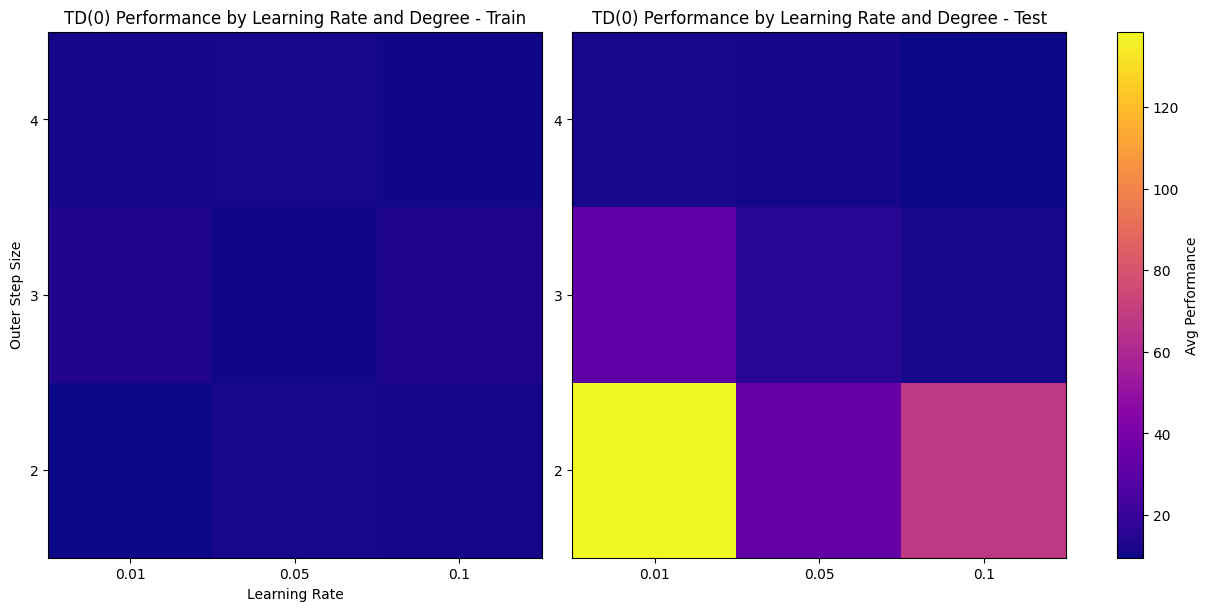

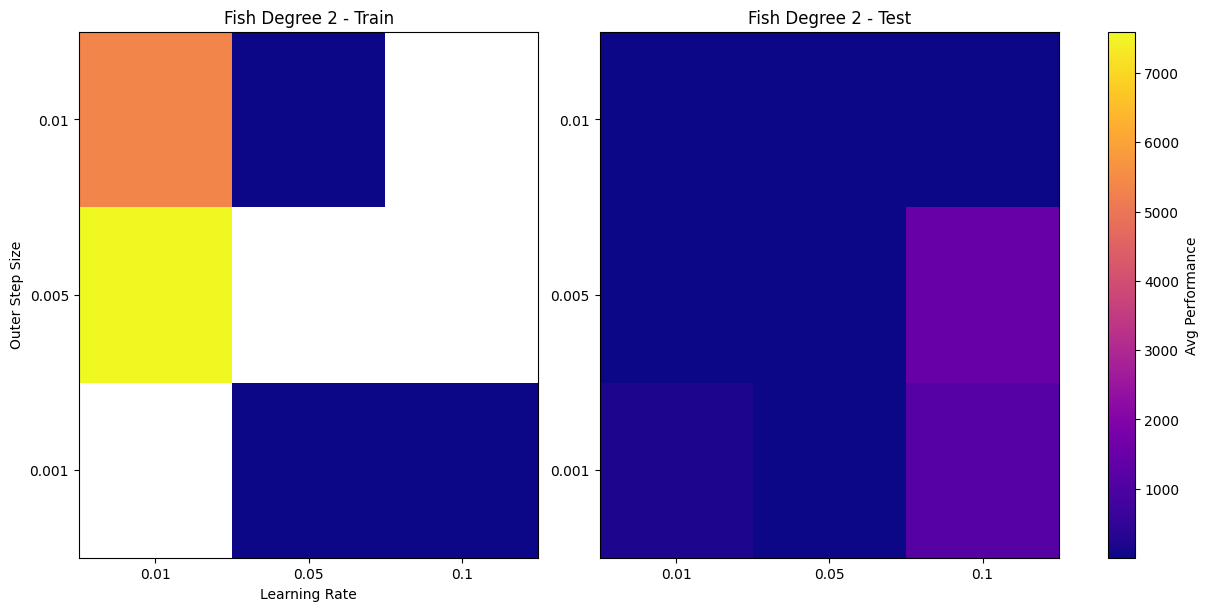

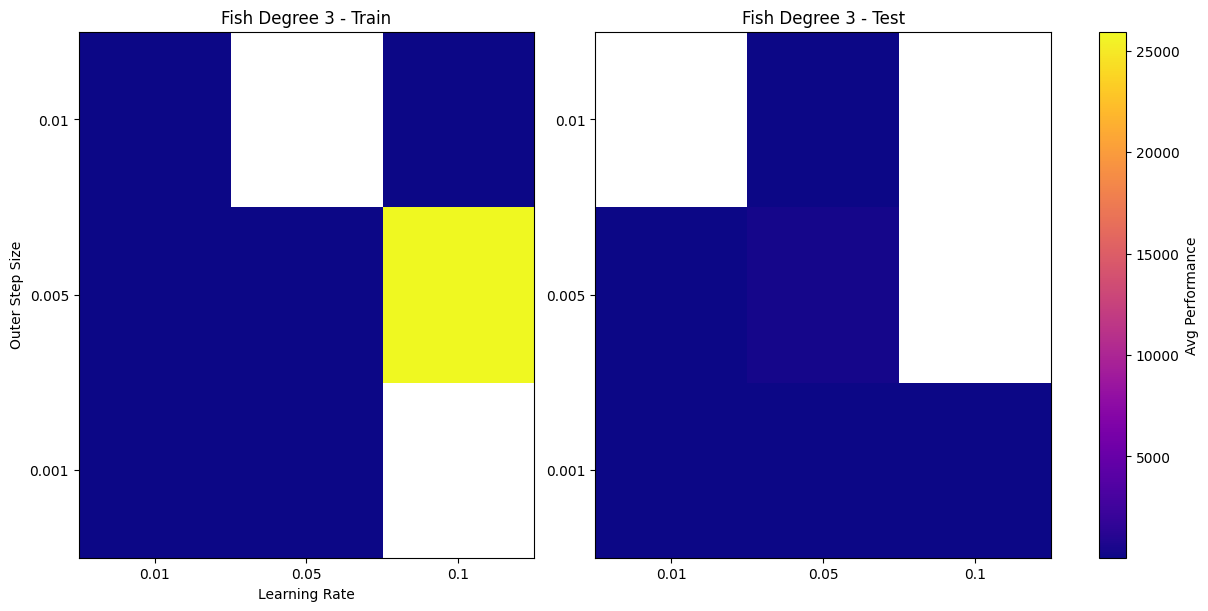

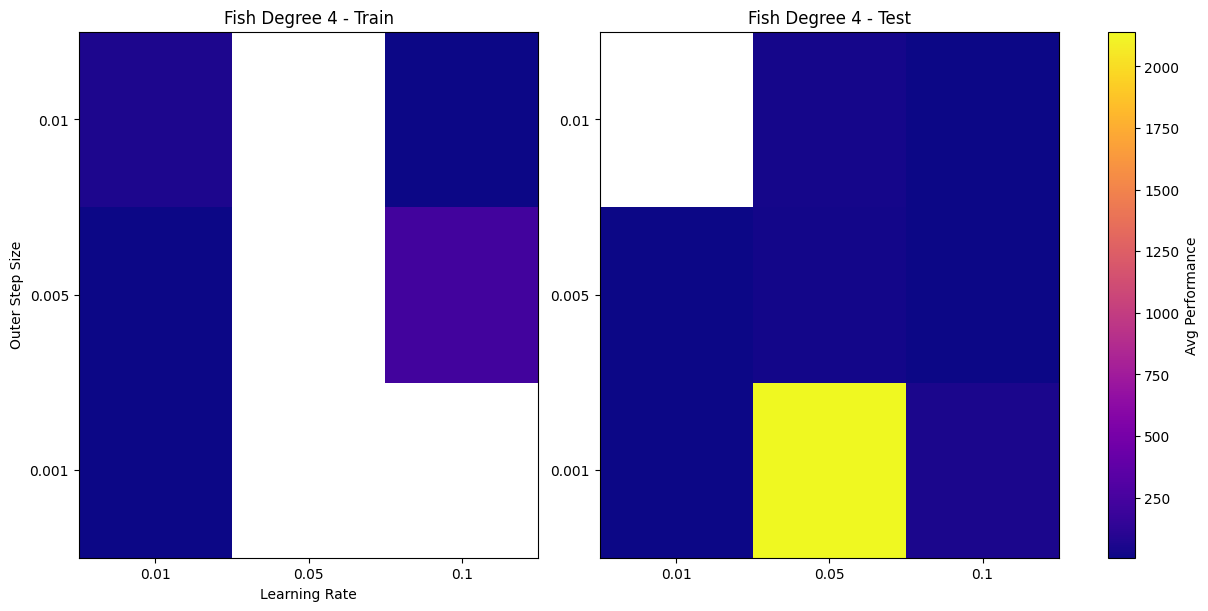

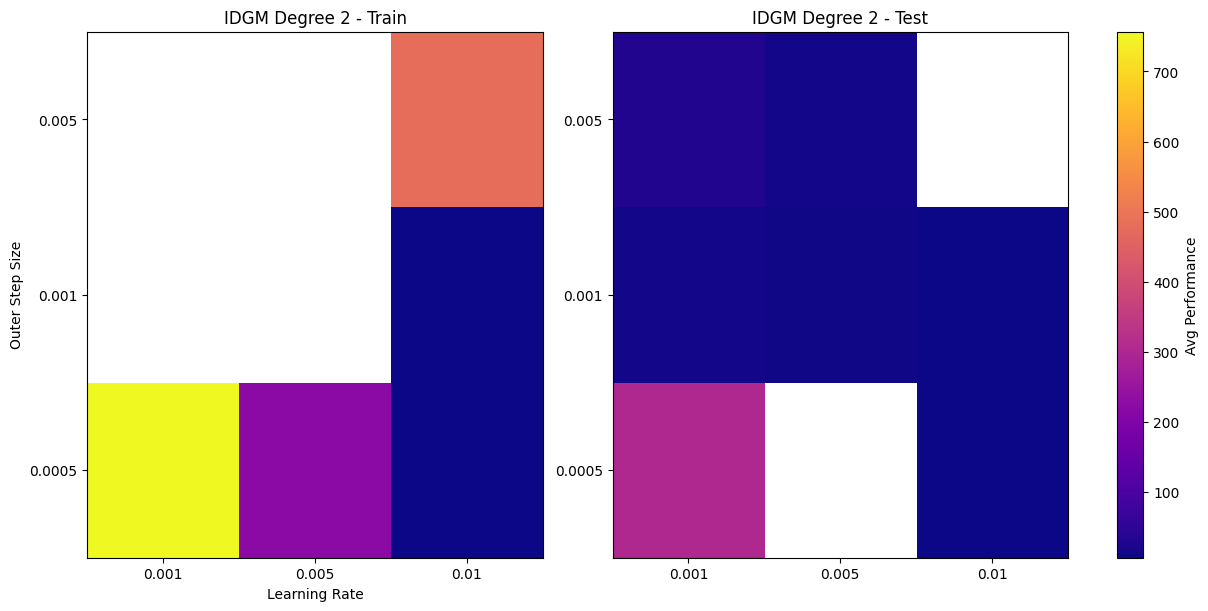

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gspread
from google.auth import default
import time

# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Divergence threshold
DIVERGENCE_THRESHOLD = 50000

# Fetch data for heatmap with divergence filtering
def fetch_data(algorithm, params, degree, metric_col):
    heatmap_data = np.zeros((len(params[1]), len(params[0])))
    for i, lr in enumerate(params[0]):
        for j, outer_step in enumerate(params[1]):
            try:
                # Create worksheet identifier based on parameter indices.
                param_indices = [i + 1, j + 1, params[2].index(degree) + 1]
                worksheet_name = f"{algorithm} {''.join(map(str, param_indices))}"
                worksheet = gc.open('Combined Data Tables AP Research').worksheet(worksheet_name)
                # Fetch metric values (skipping header rows)
                metric_values = np.array(worksheet.col_values(metric_col)[3:], dtype=np.float64)
                # Check if the trial diverged; if any value exceeds threshold, ignore this trial.
                if np.max(metric_values) > DIVERGENCE_THRESHOLD:
                    avg_performance = np.nan
                else:
                    # Average over the last 10 episodes (1000//100 equals 10)
                    avg_performance = np.mean(metric_values[-1000//100:])
                heatmap_data[j, i] = avg_performance
            except Exception as e:
                print(f"Failed to fetch data for {algorithm} with lr={lr}, outer_step={outer_step}, degree={degree}: {e}")
                heatmap_data[j, i] = np.nan
            time.sleep(1)
    return heatmap_data

# Plotting function using constrained_layout to avoid tight_layout warnings
def plot_side_by_side_heatmaps(train_data, test_data, lr_values, outer_step_values, title):
    # Use constrained_layout for automatic layout adjustment
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    # Set normalization using the combined range from both datasets.
    norm = plt.Normalize(vmin=min(np.nanmin(train_data), np.nanmin(test_data)),
                         vmax=max(np.nanmax(train_data), np.nanmax(test_data)))

    # Plot Train heatmap
    im1 = axes[0].imshow(train_data, cmap='plasma', norm=norm, aspect='auto', origin='lower')
    axes[0].set_xticks(np.arange(len(lr_values)))
    axes[0].set_yticks(np.arange(len(outer_step_values)))
    axes[0].set_xticklabels(lr_values)
    axes[0].set_yticklabels(outer_step_values)
    axes[0].set_title(f'{title} - Train')
    axes[0].set_xlabel('Learning Rate')
    axes[0].set_ylabel('Outer Step Size')

    # Plot Test heatmap
    im2 = axes[1].imshow(test_data, cmap='plasma', norm=norm, aspect='auto', origin='lower')
    axes[1].set_xticks(np.arange(len(lr_values)))
    axes[1].set_yticks(np.arange(len(outer_step_values)))
    axes[1].set_xticklabels(lr_values)
    axes[1].set_yticklabels(outer_step_values)
    axes[1].set_title(f'{title} - Test')

    fig.colorbar(im1, ax=axes.ravel().tolist(), label='Avg Performance')
    plt.show()

# Parameters for Fish and IDGM
td0_param = [[0.01, 0.05, 0.1], [2, 3, 4]]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]]

# Special handling for TD(0) — one heatmap with degree on the y-axis
train_data_td0 = np.zeros((len(td0_param[1]), len(td0_param[0])))
test_data_td0 = np.zeros((len(td0_param[1]), len(td0_param[0])))
for i, lr in enumerate(td0_param[0]):
    for j, degree in enumerate(td0_param[1]):
        try:
            param_indices = [i + 1, j + 1]
            worksheet_name = f"td(0) {''.join(map(str, param_indices))}"
            worksheet = gc.open('Combined Data Tables AP Research').worksheet(worksheet_name)
            train_values = np.array(worksheet.col_values(3)[3:], dtype=np.float64)
            test_values  = np.array(worksheet.col_values(4)[3:], dtype=np.float64)
            # If either train or test values exceed the divergence threshold, ignore this trial.
            if np.max(train_values) > DIVERGENCE_THRESHOLD or np.max(test_values) > DIVERGENCE_THRESHOLD:
                train_data_td0[j, i] = np.nan
                test_data_td0[j, i]  = np.nan
            else:
                train_data_td0[j, i] = np.mean(train_values[-1000//100:])
                test_data_td0[j, i]  = np.mean(test_values[-1000//100:])
        except Exception as e:
            print(f"Failed to fetch data for TD(0) with lr={lr}, degree={degree}: {e}")
            train_data_td0[j, i] = np.nan
            test_data_td0[j, i] = np.nan
        time.sleep(1)

plot_side_by_side_heatmaps(train_data_td0, test_data_td0, td0_param[0], td0_param[1], 'TD(0) Performance by Learning Rate and Degree')

# Plotting for Fish and IDGM
for algorithm, params in [('Fish', fish_param), ('IDGM', idgm_param)]:
    for degree in params[2]:
        train_data = fetch_data(algorithm, params, degree, metric_col=3)  # Train metric column
        test_data  = fetch_data(algorithm, params, degree, metric_col=4)  # Test metric column
        plot_side_by_side_heatmaps(train_data, test_data, params[0], params[1], f'{algorithm} Degree {degree}')


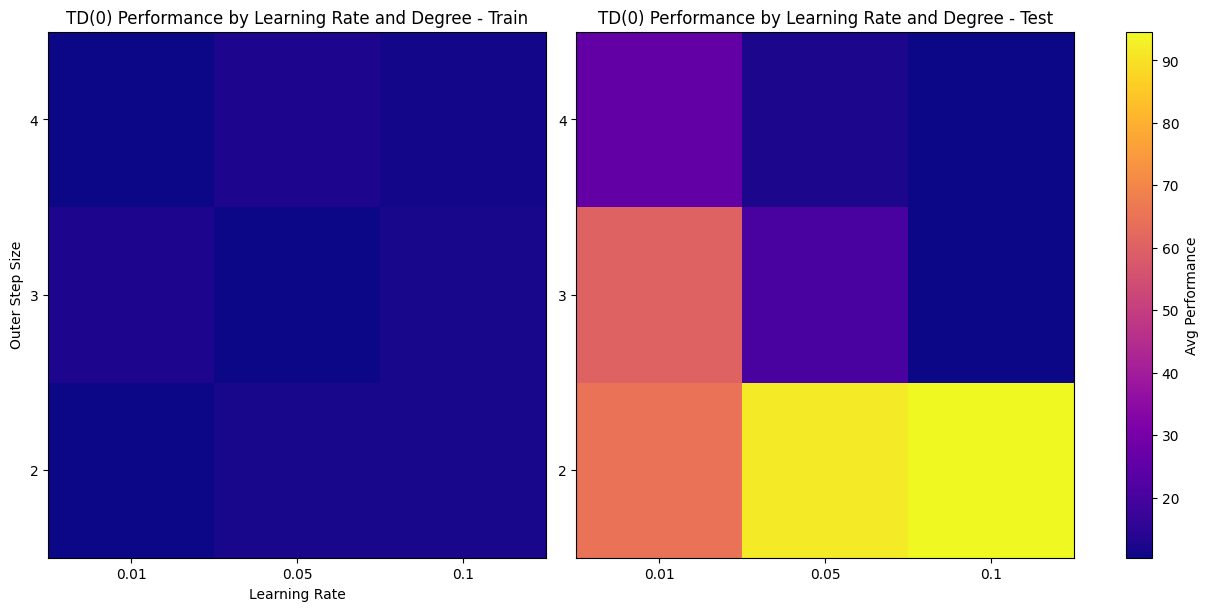

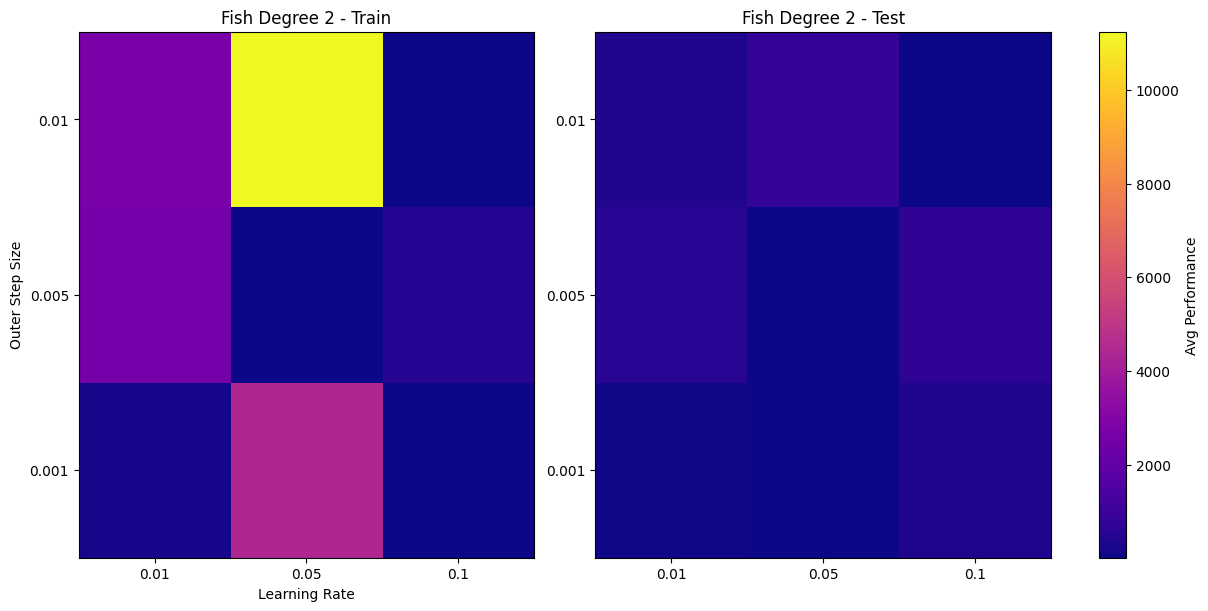

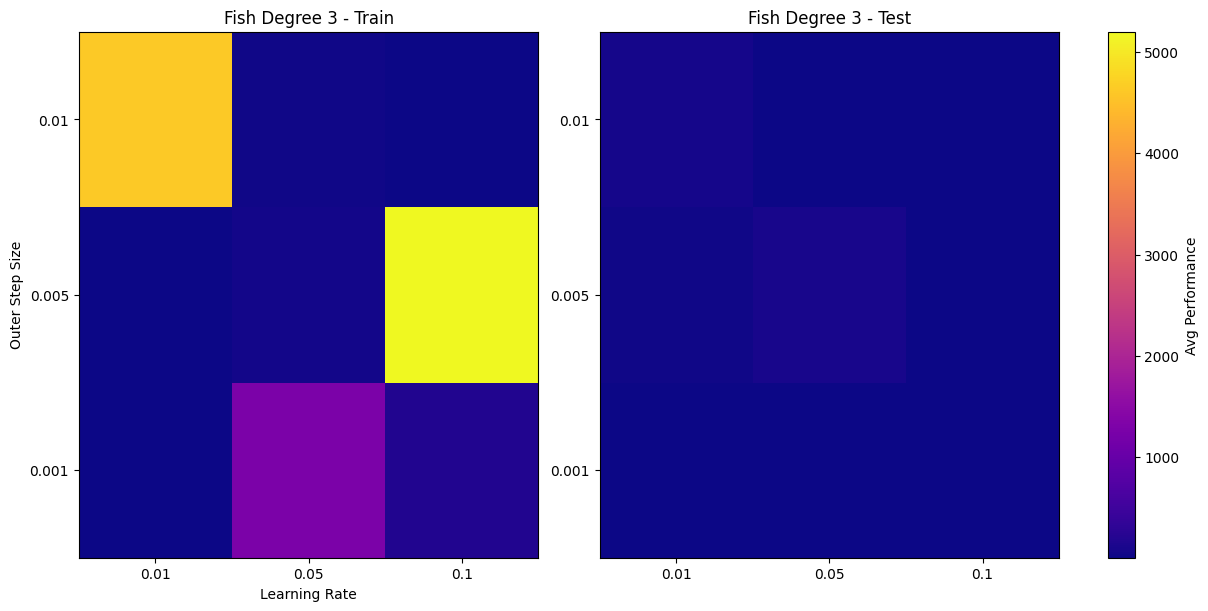

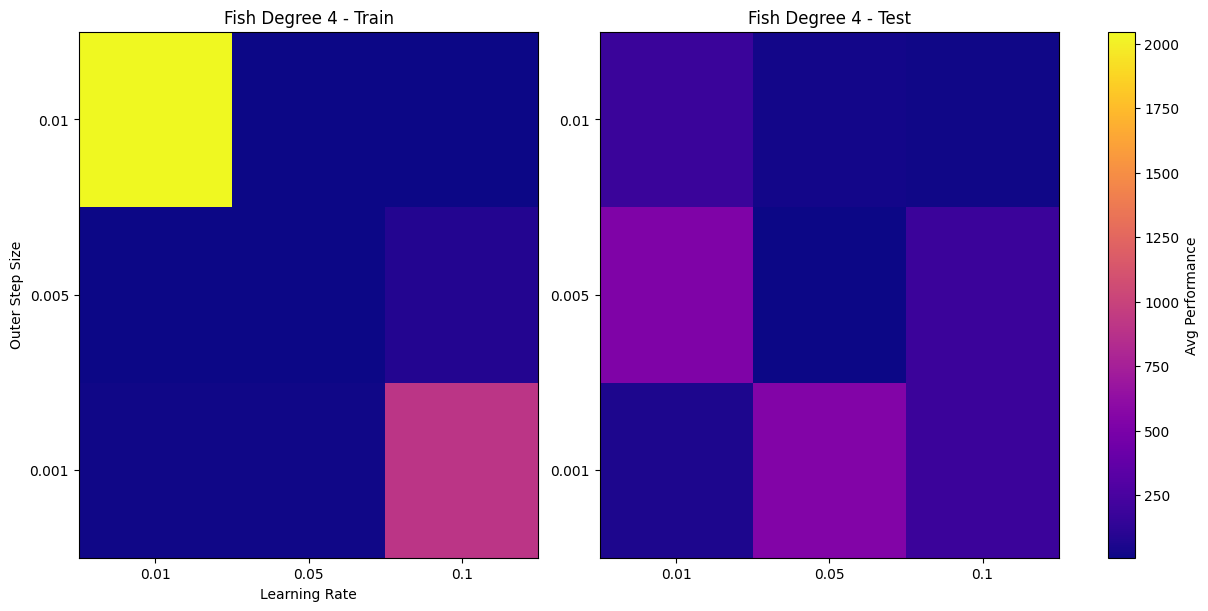

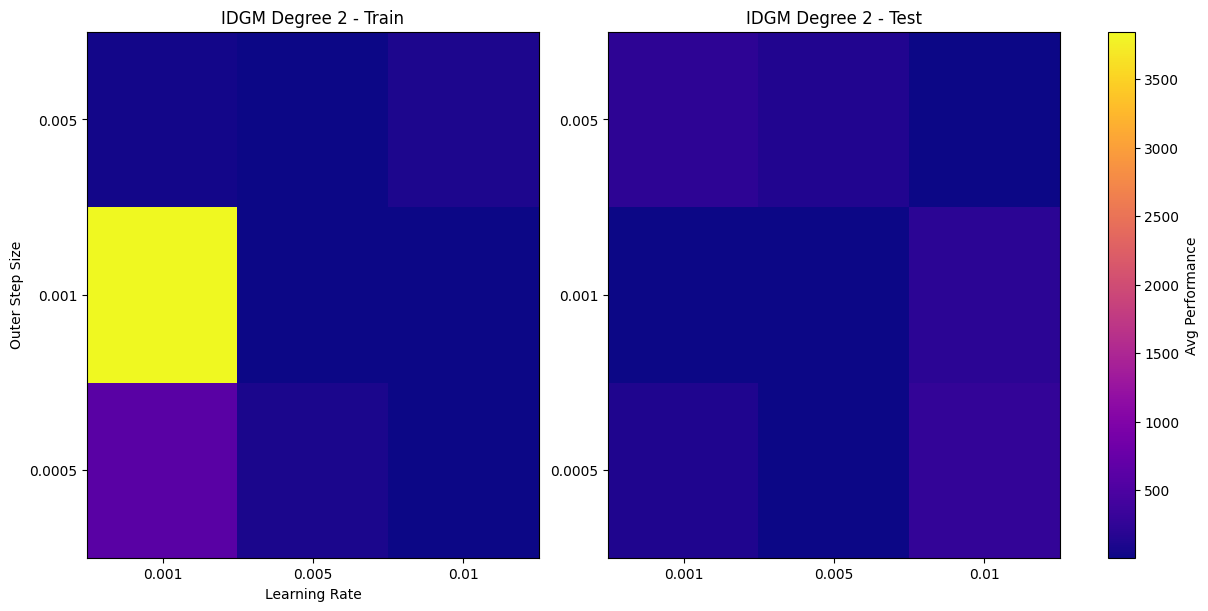

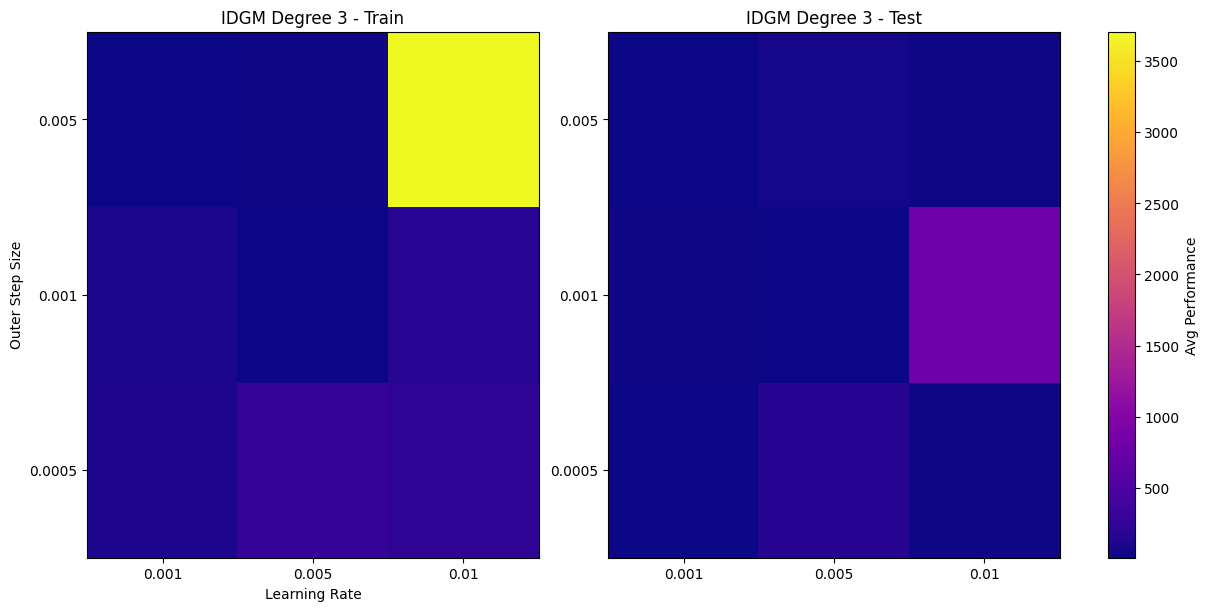

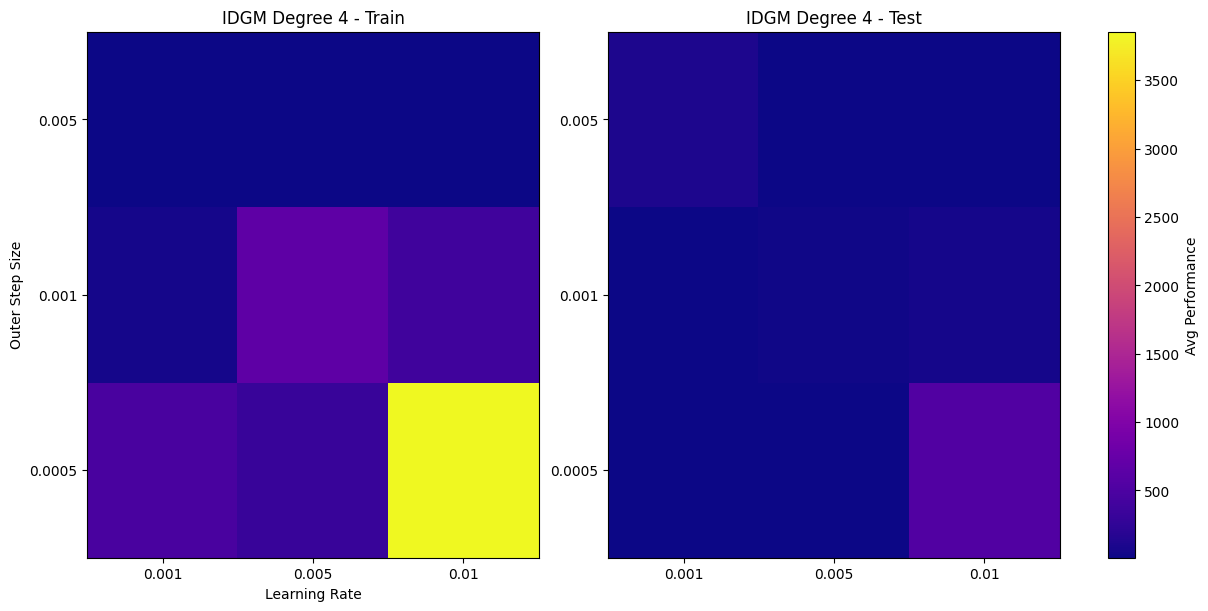

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gspread
from google.auth import default
import time

# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Divergence threshold remains at 50,000
DIVERGENCE_THRESHOLD = 50000

# Define the column indices for trials
train_columns = [3, 8, 13, 18, 23]  # Columns for training average values
test_columns  = [4, 9, 14, 19, 24]   # Columns for testing average values

# Fetch data for heatmap with divergence filtering for multiple trials.
# For each trial, if its max value is below or equal to the threshold, we take its average over the last 1000 episodes.
def fetch_data(algorithm, params, degree, metric_col_indices):
    heatmap_data = np.zeros((len(params[1]), len(params[0])))
    for i, lr in enumerate(params[0]):
        for j, outer_step in enumerate(params[1]):
            try:
                param_indices = [i + 1, j + 1, params[2].index(degree) + 1]
                worksheet_name = f"{algorithm} {''.join(map(str, param_indices))}"
                worksheet = gc.open('Combined Data Tables AP Research').worksheet(worksheet_name)

                # Collect trial data for each column index
                trial_values = []
                for col in metric_col_indices:
                    metric_values = np.array(worksheet.col_values(col)[3:], dtype=np.float64)
                    trial_values.append(metric_values)

                # Compute average only for valid (non-diverged) trials
                valid_trial_avgs = []
                for trial in trial_values:
                    # Only include this trial if its maximum value is at most the divergence threshold
                    if np.max(trial) <= DIVERGENCE_THRESHOLD:
                        # Average over the last 1000 episodes (i.e. the last 10 data points if episodes step is 100)
                        valid_trial_avgs.append(np.mean(trial[-1000//100:]))

                if len(valid_trial_avgs) == 0:
                    avg_performance = np.nan
                else:
                    avg_performance = np.mean(valid_trial_avgs)

                heatmap_data[j, i] = avg_performance
            except Exception as e:
                print(f"Failed to fetch data for {algorithm} with lr={lr}, outer_step={outer_step}, degree={degree}: {e}")
                heatmap_data[j, i] = np.nan
            time.sleep(1)
    return heatmap_data

# Plotting function using constrained_layout to avoid tight_layout warnings
def plot_side_by_side_heatmaps(train_data, test_data, lr_values, outer_step_values, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    norm = plt.Normalize(vmin=min(np.nanmin(train_data), np.nanmin(test_data)),
                         vmax=max(np.nanmax(train_data), np.nanmax(test_data)))

    im1 = axes[0].imshow(train_data, cmap='plasma', norm=norm, aspect='auto', origin='lower')
    axes[0].set_xticks(np.arange(len(lr_values)))
    axes[0].set_yticks(np.arange(len(outer_step_values)))
    axes[0].set_xticklabels(lr_values)
    axes[0].set_yticklabels(outer_step_values)
    axes[0].set_title(f'{title} - Train')
    axes[0].set_xlabel('Learning Rate')
    axes[0].set_ylabel('Outer Step Size')

    im2 = axes[1].imshow(test_data, cmap='plasma', norm=norm, aspect='auto', origin='lower')
    axes[1].set_xticks(np.arange(len(lr_values)))
    axes[1].set_yticks(np.arange(len(outer_step_values)))
    axes[1].set_xticklabels(lr_values)
    axes[1].set_yticklabels(outer_step_values)
    axes[1].set_title(f'{title} - Test')

    fig.colorbar(im1, ax=axes.ravel().tolist(), label='Avg Performance')
    plt.show()

# Parameters for Fish and IDGM
td0_param   = [[0.01, 0.05, 0.1], [2, 3, 4]]
fish_param  = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]
idgm_param  = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]]

# Special handling for TD(0) — one heatmap with degree on the y-axis
train_data_td0 = np.zeros((len(td0_param[1]), len(td0_param[0])))
test_data_td0  = np.zeros((len(td0_param[1]), len(td0_param[0])))
for i, lr in enumerate(td0_param[0]):
    for j, degree in enumerate(td0_param[1]):
        try:
            param_indices = [i + 1, j + 1]
            worksheet_name = f"td(0) {''.join(map(str, param_indices))}"
            worksheet = gc.open('Combined Data Tables AP Research').worksheet(worksheet_name)

            # For TD(0) we use the pre-defined trial columns
            train_values = [np.array(worksheet.col_values(col)[3:], dtype=np.float64) for col in train_columns]
            test_values  = [np.array(worksheet.col_values(col)[3:], dtype=np.float64) for col in test_columns]

            # For TD(0), if any trial diverges then discard all trials for that hyperparameter combination
            if any(np.max(trial) > DIVERGENCE_THRESHOLD for trial in train_values) or \
               any(np.max(trial) > DIVERGENCE_THRESHOLD for trial in test_values):
                train_data_td0[j, i] = np.nan
                test_data_td0[j, i]  = np.nan
            else:
                train_data_td0[j, i] = np.mean([np.mean(trial[-1000//100:]) for trial in train_values])
                test_data_td0[j, i]  = np.mean([np.mean(trial[-1000//100:]) for trial in test_values])
        except Exception as e:
            print(f"Failed to fetch data for TD(0) with lr={lr}, degree={degree}: {e}")
            train_data_td0[j, i] = np.nan
            test_data_td0[j, i] = np.nan
        time.sleep(1)

plot_side_by_side_heatmaps(train_data_td0, test_data_td0, td0_param[0], td0_param[1],
                           'TD(0) Performance by Learning Rate and Degree')

# For Fish and IDGM, use the same divergence logic as above.
for algorithm, params in [('Fish', fish_param), ('IDGM', idgm_param)]:
    for degree in params[2]:
        train_data = fetch_data(algorithm, params, degree, train_columns)  # Train metric columns
        test_data  = fetch_data(algorithm, params, degree, test_columns)   # Test metric columns
        plot_side_by_side_heatmaps(train_data, test_data, params[0], params[1],
                                   f'{algorithm} Degree {degree}')

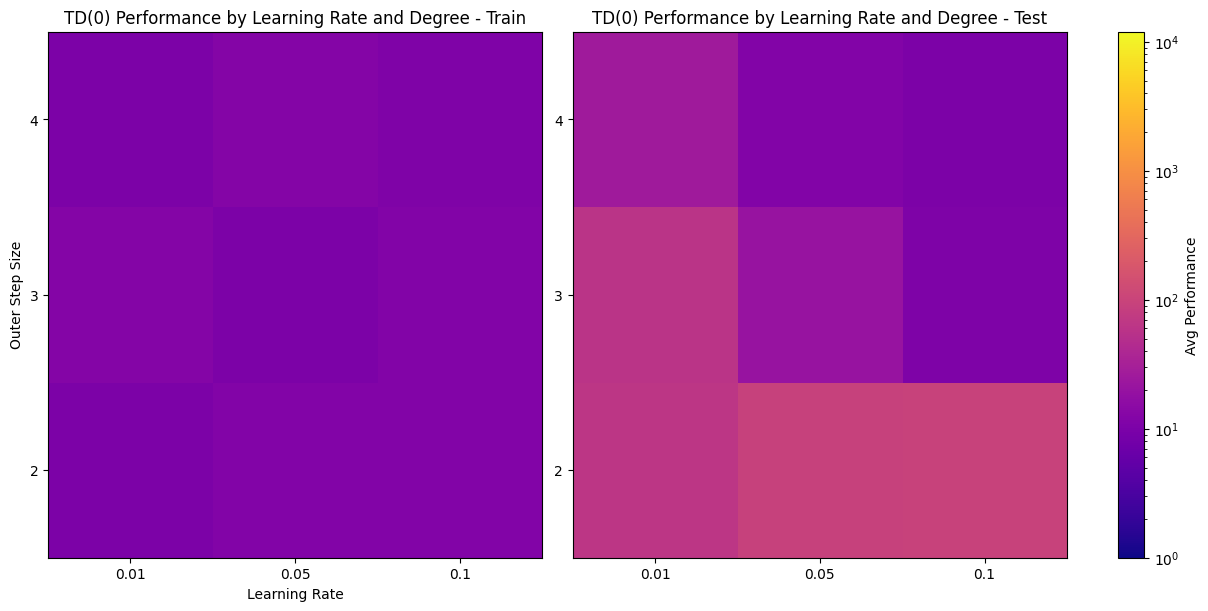

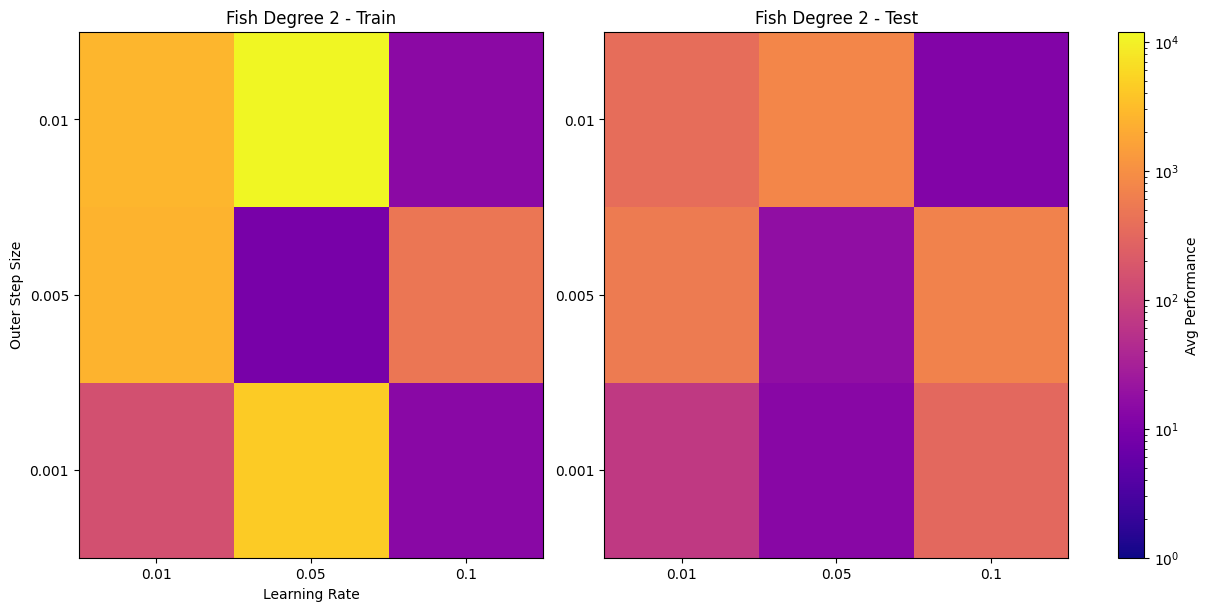

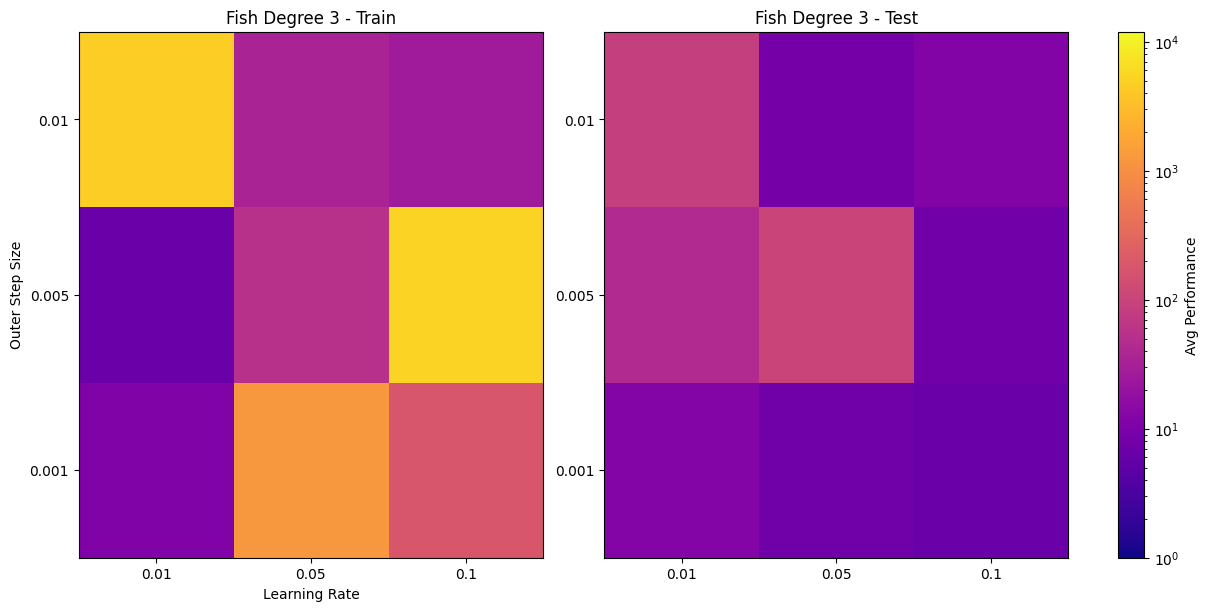

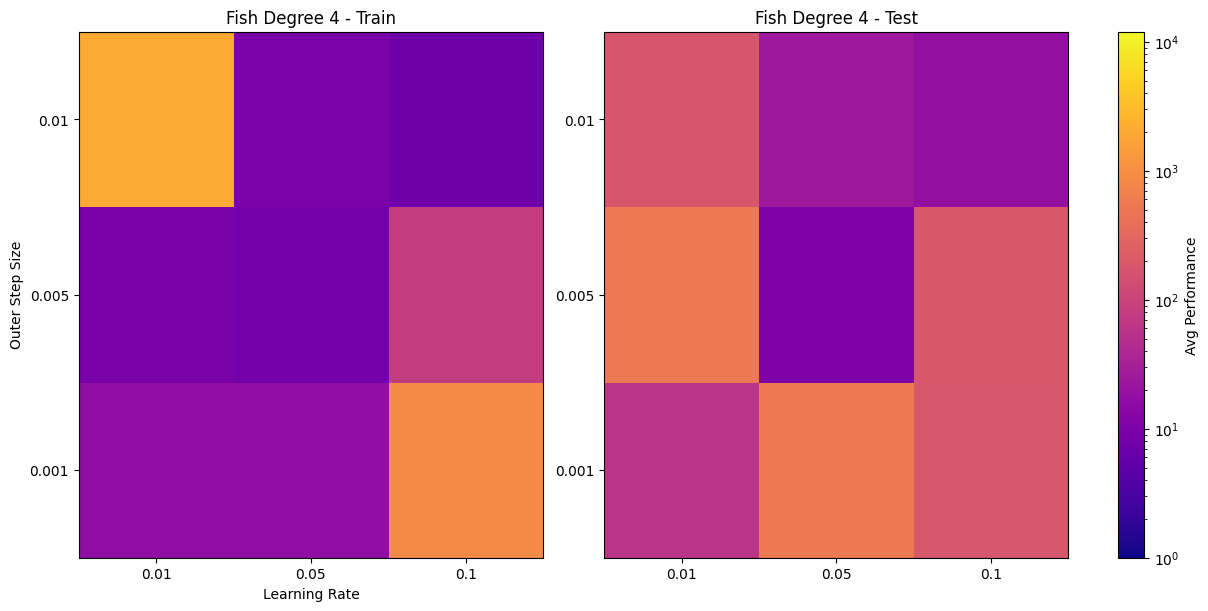

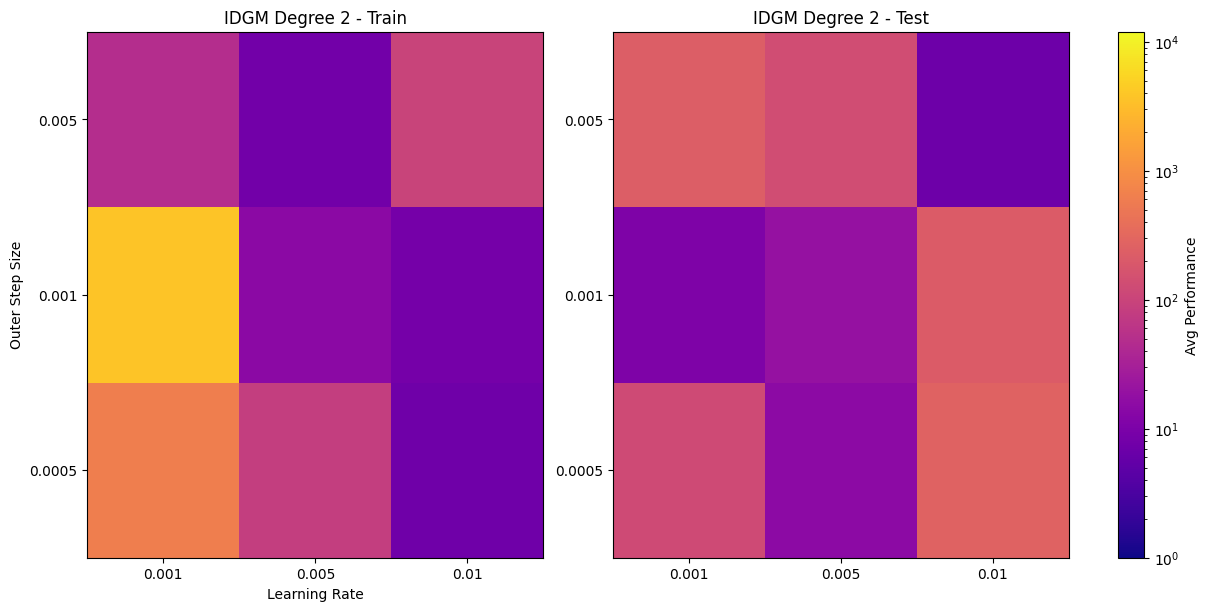

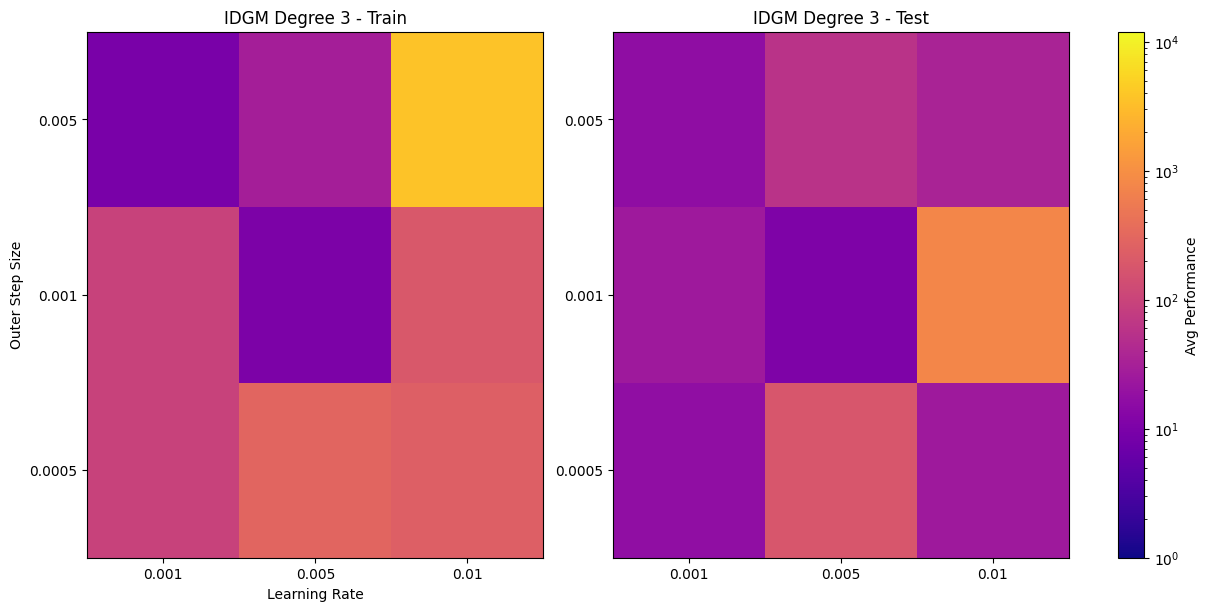

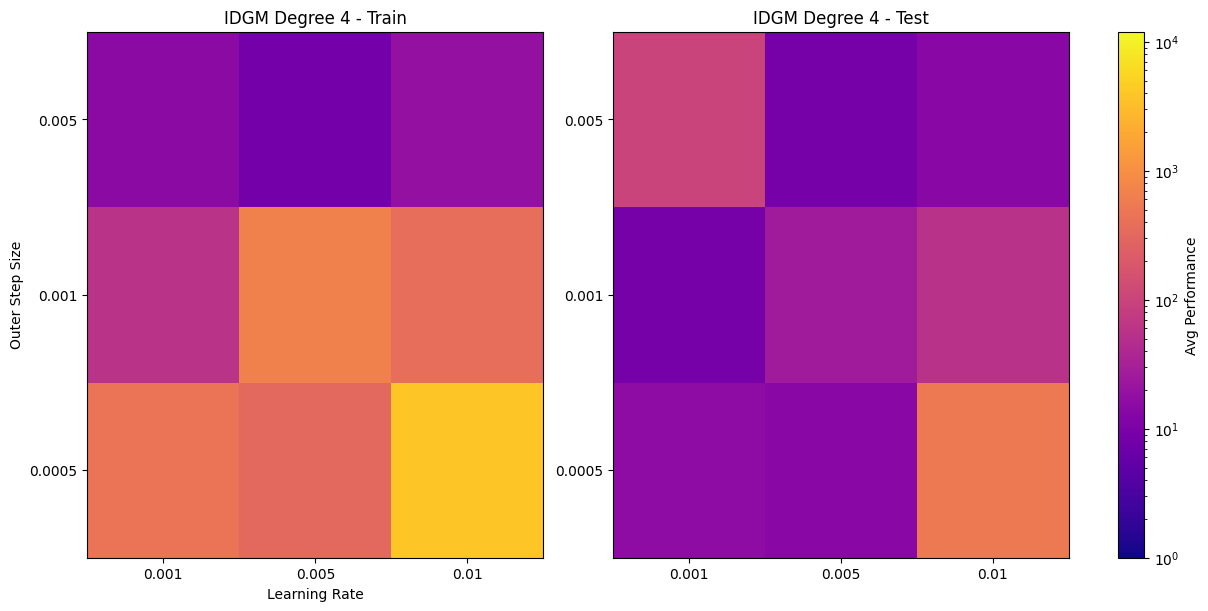

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gspread
from google.auth import default
import time
import matplotlib.colors as colors  # Import LogNorm

# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Divergence threshold remains at 50,000
DIVERGENCE_THRESHOLD = 50000

# Define the column indices for trials
train_columns = [3, 8, 13, 18, 23]  # Columns for training average values
test_columns  = [4, 9, 14, 19, 24]   # Columns for testing average values

# Fetch data for heatmap with divergence filtering for multiple trials.
# For each trial, if its max value is below or equal to the threshold, we take its average over the last 1000 episodes.
def fetch_data(algorithm, params, degree, metric_col_indices):
    heatmap_data = np.zeros((len(params[1]), len(params[0])))
    for i, lr in enumerate(params[0]):
        for j, outer_step in enumerate(params[1]):
            try:
                param_indices = [i + 1, j + 1, params[2].index(degree) + 1]
                worksheet_name = f"{algorithm} {''.join(map(str, param_indices))}"
                worksheet = gc.open('Combined Data Tables AP Research').worksheet(worksheet_name)

                # Collect trial data for each column index
                trial_values = []
                for col in metric_col_indices:
                    metric_values = np.array(worksheet.col_values(col)[3:], dtype=np.float64)
                    trial_values.append(metric_values)

                # Compute average only for valid (non-diverged) trials
                valid_trial_avgs = []
                for trial in trial_values:
                    # Only include this trial if its maximum value is at most the divergence threshold
                    if np.max(trial) <= DIVERGENCE_THRESHOLD:
                        # Average over the last 1000 episodes (i.e. the last 10 data points if episodes step is 100)
                        valid_trial_avgs.append(np.mean(trial[-1000//100:]))

                if len(valid_trial_avgs) == 0:
                    avg_performance = np.nan
                else:
                    avg_performance = np.mean(valid_trial_avgs)

                heatmap_data[j, i] = avg_performance
            except Exception as e:
                print(f"Failed to fetch data for {algorithm} with lr={lr}, outer_step={outer_step}, degree={degree}: {e}")
                heatmap_data[j, i] = np.nan
            time.sleep(1)
    return heatmap_data

# Plotting function using LogNorm for a logarithmic color scale and constrained_layout for layout.
def plot_side_by_side_heatmaps(train_data, test_data, lr_values, outer_step_values, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    # Define a logarithmic normalization from 1 to 12,000
    lognorm = colors.LogNorm(vmin=1, vmax=12000)

    # Use the same log normalization for both train and test plots
    im1 = axes[0].imshow(train_data, cmap='plasma', norm=lognorm, aspect='auto', origin='lower')
    axes[0].set_xticks(np.arange(len(lr_values)))
    axes[0].set_yticks(np.arange(len(outer_step_values)))
    axes[0].set_xticklabels(lr_values)
    axes[0].set_yticklabels(outer_step_values)
    axes[0].set_title(f'{title} - Train')
    axes[0].set_xlabel('Learning Rate')
    axes[0].set_ylabel('Outer Step Size')

    im2 = axes[1].imshow(test_data, cmap='plasma', norm=lognorm, aspect='auto', origin='lower')
    axes[1].set_xticks(np.arange(len(lr_values)))
    axes[1].set_yticks(np.arange(len(outer_step_values)))
    axes[1].set_xticklabels(lr_values)
    axes[1].set_yticklabels(outer_step_values)
    axes[1].set_title(f'{title} - Test')

    # Create a shared colorbar with a label indicating a logarithmic scale
    fig.colorbar(im1, ax=axes.ravel().tolist(), label='Avg Performance')
    plt.show()

# Parameters for Fish and IDGM
td0_param   = [[0.01, 0.05, 0.1], [2, 3, 4]]
fish_param  = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]
idgm_param  = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]]

# Special handling for TD(0) — one heatmap with degree on the y-axis
train_data_td0 = np.zeros((len(td0_param[1]), len(td0_param[0])))
test_data_td0  = np.zeros((len(td0_param[1]), len(td0_param[0])))
for i, lr in enumerate(td0_param[0]):
    for j, degree in enumerate(td0_param[1]):
        try:
            param_indices = [i + 1, j + 1]
            worksheet_name = f"td(0) {''.join(map(str, param_indices))}"
            worksheet = gc.open('Combined Data Tables AP Research').worksheet(worksheet_name)

            # For TD(0) we use the pre-defined trial columns
            train_values = [np.array(worksheet.col_values(col)[3:], dtype=np.float64) for col in train_columns]
            test_values  = [np.array(worksheet.col_values(col)[3:], dtype=np.float64) for col in test_columns]

            # For TD(0), if any trial diverges then discard all trials for that hyperparameter combination
            if any(np.max(trial) > DIVERGENCE_THRESHOLD for trial in train_values) or \
               any(np.max(trial) > DIVERGENCE_THRESHOLD for trial in test_values):
                train_data_td0[j, i] = np.nan
                test_data_td0[j, i]  = np.nan
            else:
                train_data_td0[j, i] = np.mean([np.mean(trial[-1000//100:]) for trial in train_values])
                test_data_td0[j, i]  = np.mean([np.mean(trial[-1000//100:]) for trial in test_values])
        except Exception as e:
            print(f"Failed to fetch data for TD(0) with lr={lr}, degree={degree}: {e}")
            train_data_td0[j, i] = np.nan
            test_data_td0[j, i] = np.nan
        time.sleep(1)

plot_side_by_side_heatmaps(train_data_td0, test_data_td0, td0_param[0], td0_param[1],
                           'TD(0) Performance by Learning Rate and Degree')

# For Fish and IDGM, use the same divergence logic as above.
for algorithm, params in [('Fish', fish_param), ('IDGM', idgm_param)]:
    for degree in params[2]:
        train_data = fetch_data(algorithm, params, degree, train_columns)  # Train metric columns
        test_data  = fetch_data(algorithm, params, degree, test_columns)   # Test metric columns
        plot_side_by_side_heatmaps(train_data, test_data, params[0], params[1],
                                   f'{algorithm} Degree {degree}')

In [ ]:
import numpy as np
import gspread
import itertools
import time
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Number of episodes to average over (last 1000 episodes)
n_last = 1000 // 100  # Assuming data recorded every 100 episodes

def fetch_configuration_metrics(algorithm, param_indices, is_td0=False):
    """
    For a given worksheet (specified by the hyperparameter indices in param_indices),
    fetch the arrays for train policy performance, test policy performance,
    train MSE and test MSE for each of the 5 trials, extract the last n_last values,
    and then average across trials.

    Returns:
        best_metrics: dict with keys 'train_policy', 'test_policy', 'train_MSE', 'test_MSE'
                      each is an array of length n_last.
    """
    # Lists to collect the metric arrays for each trial
    train_policy_trials = []
    test_policy_trials = []
    train_MSE_trials = []
    test_MSE_trials = []

    # Build worksheet name
    # For TD(0) param_indices is a list of two numbers, for others it is three numbers.
    ws_name = f"{algorithm} {''.join(map(str, param_indices))}"
    try:
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(ws_name)
    except Exception as e:
        print(f"Could not open worksheet {ws_name}: {e}")
        return None

    # There are 5 trials; the data for each trial is in separate columns (offset by 5)
    for trial in range(5):
        offset = trial * 5
        try:
            # Columns: Train policy (col 3+offset), Test policy (col 4+offset),
            # Train MSE (col 5+offset), Test MSE (col 6+offset)
            train_policy_all = np.array(worksheet.col_values(3 + offset)[3:], dtype=np.float64)
            test_policy_all = np.array(worksheet.col_values(4 + offset)[3:], dtype=np.float64)
            train_MSE_all = np.array(worksheet.col_values(5 + offset)[3:], dtype=np.float64)
            test_MSE_all = np.array(worksheet.col_values(6 + offset)[3:], dtype=np.float64)

            # Extract the last n_last values (assumes the arrays are long enough)
            train_policy_trials.append(train_policy_all[-n_last:])
            test_policy_trials.append(test_policy_all[-n_last:])
            train_MSE_trials.append(train_MSE_all[-n_last:])
            test_MSE_trials.append(test_MSE_all[-n_last:])
        except Exception as e:
            print(f"Failed to fetch trial {trial} for {ws_name}: {e}")
            return None
        time.sleep(1)

    # Average across the 5 trials (axis=0 gives an array of length n_last)
    avg_train_policy = np.nanmean(np.stack(train_policy_trials), axis=0)
    avg_test_policy = np.nanmean(np.stack(test_policy_trials), axis=0)
    avg_train_MSE = np.nanmean(np.stack(train_MSE_trials), axis=0)
    avg_test_MSE = np.nanmean(np.stack(test_MSE_trials), axis=0)

    return {'train_policy': avg_train_policy,
            'test_policy': avg_test_policy,
            'train_MSE': avg_train_MSE,
            'test_MSE': avg_test_MSE}

def get_best_configuration(algorithm, param_grid):
    """
    Loop over all hyperparameter configurations for the given algorithm,
    fetch the averaged test policy performance (scalar average over last n_last episodes),
    and return the configuration (as param_indices) with the lowest average test policy performance,
    along with the averaged metric arrays for that configuration.

    param_grid: list of lists, e.g.
       For Fish and IDGM: [learning_rates, outer_step_sizes, degrees]
       For TD(0): [learning_rates, degrees]
    """
    best_config = None
    best_metrics = None
    best_avg_test = np.inf  # Initialize with infinity so that lower is better

    # Use itertools.product over the grid
    for config in itertools.product(*param_grid):
        # For TD(0), config has 2 values; for others, it has 3
        param_indices = [param_grid[i].index(value) + 1 for i, value in enumerate(config)]
        metrics = fetch_configuration_metrics(algorithm, param_indices, is_td0=(algorithm=='td(0)'))
        if metrics is None:
            continue
        # Compute a scalar average test policy performance (average over the last n_last episodes)
        avg_test = np.mean(metrics['test_policy'])
        # Check if this configuration is better (lower test policy performance)
        if avg_test < best_avg_test:
            best_avg_test = avg_test
            best_config = config
            best_metrics = metrics
        print(f"{algorithm} config {config}: Avg Test Policy = {avg_test}")

    if best_config is not None:
        print(f"\nBest configuration for {algorithm}: {best_config} with average test policy performance = {best_avg_test}\n")
    else:
        print(f"No valid configuration found for {algorithm}")
    return best_config, best_metrics

# Define the parameter grids
td0_param = [[0.01, 0.05, 0.1], [2, 3, 4]]             # [Learning Rate, Degree]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]  # [Learning Rate, Outer Step Size, Degree]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]]  # [Learning Rate, Outer Step Size, Degree]

# Process each algorithm and print the four arrays for the best configuration
for algorithm, param_grid in [('td(0)', td0_param), ('Fish', fish_param), ('IDGM', idgm_param)]:
    print(f"Processing algorithm: {algorithm}")
    best_config, best_metrics = get_best_configuration(algorithm, param_grid)
    if best_metrics is not None:
        print("Averaged Train Policy Performance (last 1000 episodes):")
        print(best_metrics['train_policy'])
        print("Averaged Test Policy Performance (last 1000 episodes):")
        print(best_metrics['test_policy'])
        print("Averaged Train MSE (last 1000 episodes):")
        print(best_metrics['train_MSE'])
        print("Averaged Test MSE (last 1000 episodes):")
        print(best_metrics['test_MSE'])
    print("-" * 100)

Processing algorithm: td(0)
td(0) config (0.01, 2): Avg Test Policy = 64.7
td(0) config (0.01, 3): Avg Test Policy = 60.480000000000004
td(0) config (0.01, 4): Avg Test Policy = 25.660000000000004
td(0) config (0.05, 2): Avg Test Policy = 91.94000000000001
td(0) config (0.05, 3): Avg Test Policy = 20.48
td(0) config (0.05, 4): Avg Test Policy = 12.12
td(0) config (0.1, 2): Avg Test Policy = 94.6
td(0) config (0.1, 3): Avg Test Policy = 10.66
td(0) config (0.1, 4): Avg Test Policy = 10.440000000000001

Best configuration for td(0): (0.1, 4) with average test policy performance = 10.440000000000001

Averaged Train Policy Performance (last 1000 episodes):
[ 7.2 11.4 10.4 13.  11.4  8.4 12.4 12.8 12.2 12. ]
Averaged Test Policy Performance (last 1000 episodes):
[11.  11.6 11.4  9.6  9.8  8.  13.2  9.8 10.8  9.2]
Averaged Train MSE (last 1000 episodes):
[0.56362 0.64252 0.669   0.6461  0.5931  0.69532 0.64938 0.6026  0.68202
 0.75632]
Averaged Test MSE (last 1000 episodes):
[0.07618 0.07616

In [ ]:
import numpy as np
import gspread
from google.auth import default
import itertools
import time

# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Number of data points from the last 1000 episodes (episodes 9000, 9100, …, 10000)
n_last = 11  # 11 data points

def fetch_configuration_metrics(algorithm, param_indices, is_td0=False):
    """
    For a given worksheet (identified by the hyperparameter indices in param_indices),
    fetch the arrays for train policy performance, test policy performance,
    train MSE and test MSE for each of the 5 trials, extract the last n_last values,
    and then average across converged trials only.

    A trial is considered converged if both its train and test policy performance
    do not exceed 50,000.

    Returns a dictionary with keys 'train_policy', 'test_policy', 'train_MSE', 'test_MSE'
    (each an array of length n_last) if at least one trial converged; otherwise, returns None.
    """
    valid_train_policy_trials = []
    valid_test_policy_trials = []
    valid_train_MSE_trials = []
    valid_test_MSE_trials = []

    ws_name = f"{algorithm} {''.join(map(str, param_indices))}"
    try:
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(ws_name)
    except Exception as e:
        print(f"Could not open worksheet {ws_name}: {e}")
        return None

    for trial in range(5):
        offset = trial * 5
        try:
            # Columns: Train policy (col 3+offset), Test policy (col 4+offset),
            # Train MSE (col 5+offset), Test MSE (col 6+offset)
            train_policy_all = np.array(worksheet.col_values(3 + offset)[3:], dtype=np.float64)
            test_policy_all = np.array(worksheet.col_values(4 + offset)[3:], dtype=np.float64)
            train_MSE_all = np.array(worksheet.col_values(5 + offset)[3:], dtype=np.float64)
            test_MSE_all = np.array(worksheet.col_values(6 + offset)[3:], dtype=np.float64)

            # Check if this trial diverged
            if np.max(train_policy_all) > 50000 or np.max(test_policy_all) > 50000:
                print(f"Trial {trial} in {ws_name} diverged. Skipping.")
                continue

            # Extract the last n_last values (episodes 9000 to 10000)
            valid_train_policy_trials.append(train_policy_all[-n_last:])
            valid_test_policy_trials.append(test_policy_all[-n_last:])
            valid_train_MSE_trials.append(train_MSE_all[-n_last:])
            valid_test_MSE_trials.append(test_MSE_all[-n_last:])
        except Exception as e:
            print(f"Failed to fetch trial {trial} for {ws_name}: {e}")
            continue
        time.sleep(1)

    if len(valid_train_policy_trials) == 0:
        return None

    avg_train_policy = np.nanmean(np.stack(valid_train_policy_trials), axis=0)
    avg_test_policy = np.nanmean(np.stack(valid_test_policy_trials), axis=0)
    avg_train_MSE = np.nanmean(np.stack(valid_train_MSE_trials), axis=0)
    avg_test_MSE = np.nanmean(np.stack(valid_test_MSE_trials), axis=0)

    return {'train_policy': avg_train_policy,
            'test_policy': avg_test_policy,
            'train_MSE': avg_train_MSE,
            'test_MSE': avg_test_MSE}

def get_best_configuration(algorithm, param_grid):
    """
    Loop over all hyperparameter configurations for the given algorithm,
    fetch the averaged test policy performance (scalar average over the last n_last episodes)
    using converged trials only, and return the configuration (and its averaged metrics)
    with the lowest average test policy performance.
    """
    best_config = None
    best_metrics = None
    best_avg_test = np.inf

    for config in itertools.product(*param_grid):
        param_indices = [param_grid[i].index(value) + 1 for i, value in enumerate(config)]
        metrics = fetch_configuration_metrics(algorithm, param_indices, is_td0=(algorithm=='td(0)'))
        if metrics is None:
            continue
        avg_test = np.mean(metrics['test_policy'])
        print(f"{algorithm} config {config}: Avg Test Policy = {avg_test}")
        if avg_test < best_avg_test:
            best_avg_test = avg_test
            best_config = config
            best_metrics = metrics

    if best_config is not None:
        print(f"\nBest configuration for {algorithm}: {best_config} with average test policy performance = {best_avg_test}\n")
    else:
        print(f"No valid configuration found for {algorithm}")
    return best_config, best_metrics

# Define parameter grids
td0_param = [[0.01, 0.05, 0.1], [2, 3, 4]]              # [Learning Rate, Degree]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]   # [Learning Rate, Outer Step Size, Degree]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]]  # [Learning Rate, Outer Step Size, Degree]

# Process each algorithm and print the four arrays for the best configuration
for algorithm, param_grid in [('td(0)', td0_param), ('Fish', fish_param), ('IDGM', idgm_param)]:
    print(f"Processing algorithm: {algorithm}")
    best_config, best_metrics = get_best_configuration(algorithm, param_grid)
    if best_metrics is not None:
        print("Averaged Train Policy Performance (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in best_metrics['train_policy'])))
        print("Averaged Test Policy Performance (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in best_metrics['test_policy'])))
        print("Averaged Train MSE (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in best_metrics['train_MSE'])))
        print("Averaged Test MSE (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in best_metrics['test_MSE'])))
    print("-" * 100)

Processing algorithm: td(0)
td(0) config (0.01, 2): Avg Test Policy = 60.654545454545456
td(0) config (0.01, 3): Avg Test Policy = 57.963636363636375
td(0) config (0.01, 4): Avg Test Policy = 24.30909090909091
td(0) config (0.05, 2): Avg Test Policy = 86.9090909090909
td(0) config (0.05, 3): Avg Test Policy = 19.49090909090909
td(0) config (0.05, 4): Avg Test Policy = 12.109090909090908
td(0) config (0.1, 2): Avg Test Policy = 94.38181818181816
td(0) config (0.1, 3): Avg Test Policy = 10.472727272727273
td(0) config (0.1, 4): Avg Test Policy = 10.345454545454546

Best configuration for td(0): (0.1, 4) with average test policy performance = 10.345454545454546

Averaged Train Policy Performance (last 1000 episodes):
[10.200, 7.200, 11.400, 10.400, 13.000, 11.400, 8.400, 12.400, 12.800, 12.200, 12.000]
Averaged Test Policy Performance (last 1000 episodes):
[9.400, 11.000, 11.600, 11.400, 9.600, 9.800, 8.000, 13.200, 9.800, 10.800, 9.200]
Averaged Train MSE (last 1000 episodes):
[0.609, 0.

In [ ]:
import numpy as np
import gspread
from google.auth import default
import itertools
import time
from google.colab import auth
auth.authenticate_user()
# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Number of data points from the last 1000 episodes (episodes 9000, 9100, …, 10000)
n_last = 11  # 11 data points

def fetch_converged_trials(algorithm, param_indices):
    """
    For a given worksheet (identified by the hyperparameter indices in param_indices),
    fetch the data for train policy, test policy, train MSE and test MSE for each trial.
    A trial is considered converged if neither its train nor test policy exceeds 50,000.
    Returns a dictionary with lists of arrays (one per converged trial) for each metric.
    """
    train_policy_list = []
    test_policy_list = []
    train_MSE_list = []
    test_MSE_list = []

    ws_name = f"{algorithm} {''.join(map(str, param_indices))}"
    try:
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(ws_name)
    except Exception as e:
        print(f"Could not open worksheet {ws_name}: {e}")
        return None

    for trial in range(5):
        offset = trial * 5
        try:
            # Columns: Train policy (col 3+offset), Test policy (col 4+offset),
            # Train MSE (col 5+offset), Test MSE (col 6+offset)
            train_policy_all = np.array(worksheet.col_values(3 + offset)[3:], dtype=np.float64)
            test_policy_all = np.array(worksheet.col_values(4 + offset)[3:], dtype=np.float64)
            train_MSE_all = np.array(worksheet.col_values(5 + offset)[3:], dtype=np.float64)
            test_MSE_all = np.array(worksheet.col_values(6 + offset)[3:], dtype=np.float64)

            # Check if trial diverged
            if np.max(train_policy_all) > 50000 or np.max(test_policy_all) > 50000:
                print(f"Trial {trial} in {ws_name} diverged. Skipping.")
                continue

            # Extract the last n_last values (episodes 9000 to 10000)
            train_policy_list.append(train_policy_all[-n_last:])
            test_policy_list.append(test_policy_all[-n_last:])
            train_MSE_list.append(train_MSE_all[-n_last:])
            test_MSE_list.append(test_MSE_all[-n_last:])
        except Exception as e:
            print(f"Failed to fetch trial {trial} for {ws_name}: {e}")
            continue
        time.sleep(1)

    if len(train_policy_list) == 0:
        return None

    return {
        'train_policy_trials': train_policy_list,
        'test_policy_trials': test_policy_list,
        'train_MSE_trials': train_MSE_list,
        'test_MSE_trials': test_MSE_list
    }

def get_all_converged_metrics(algorithm, param_grid):
    """
    Iterates over all hyperparameter configurations for the given algorithm,
    accumulates all converged trials' last n_last episodes for each metric,
    and returns averaged arrays for train policy, test policy, train MSE, and test MSE.
    """
    all_train_policy_trials = []
    all_test_policy_trials = []
    all_train_MSE_trials = []
    all_test_MSE_trials = []

    for config in itertools.product(*param_grid):
        param_indices = [param_grid[i].index(value) + 1 for i, value in enumerate(config)]
        metrics = fetch_converged_trials(algorithm, param_indices)
        if metrics is None:
            continue
        all_train_policy_trials.extend(metrics['train_policy_trials'])
        all_test_policy_trials.extend(metrics['test_policy_trials'])
        all_train_MSE_trials.extend(metrics['train_MSE_trials'])
        all_test_MSE_trials.extend(metrics['test_MSE_trials'])

    if len(all_train_policy_trials) == 0:
        return None

    avg_train_policy = np.nanmean(np.stack(all_train_policy_trials), axis=0)
    avg_test_policy = np.nanmean(np.stack(all_test_policy_trials), axis=0)
    avg_train_MSE = np.nanmean(np.stack(all_train_MSE_trials), axis=0)
    avg_test_MSE = np.nanmean(np.stack(all_test_MSE_trials), axis=0)

    return {
        'train_policy': avg_train_policy,
        'test_policy': avg_test_policy,
        'train_MSE': avg_train_MSE,
        'test_MSE': avg_test_MSE
    }

# Define parameter grids for each algorithm
td0_param = [[0.01, 0.05, 0.1], [2, 3, 4]]               # [Learning Rate, Degree]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]    # [Learning Rate, Outer Step Size, Degree]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]] # [Learning Rate, Outer Step Size, Degree]

# Process each algorithm and print the four averaged arrays from all converged trials
for algorithm, param_grid in [('td(0)', td0_param), ('Fish', fish_param), ('IDGM', idgm_param)]:
    print(f"Processing algorithm: {algorithm}")
    metrics = get_all_converged_metrics(algorithm, param_grid)
    if metrics is not None:
        print("Averaged Train Policy Performance (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in metrics['train_policy'])))
        print("Averaged Test Policy Performance (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in metrics['test_policy'])))
        print("Averaged Train MSE (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in metrics['train_MSE'])))
        print("Averaged Test MSE (last 1000 episodes):")
        print("[{}]".format(", ".join(f"{v:.3f}" for v in metrics['test_MSE'])))
    else:
        print(f"No converged trials found for {algorithm}")
    print("-" * 100)

Processing algorithm: td(0)
Averaged Train Policy Performance (last 1000 episodes):
[10.044, 11.311, 10.578, 11.844, 11.244, 11.222, 11.067, 11.667, 11.667, 11.756, 11.978]
Averaged Test Policy Performance (last 1000 episodes):
[25.800, 17.244, 36.200, 20.333, 88.511, 15.267, 17.000, 66.000, 47.667, 40.311, 86.000]
Averaged Train MSE (last 1000 episodes):
[0.229, 0.221, 0.229, 0.220, 0.237, 0.234, 0.256, 0.232, 0.244, 0.246, 0.252]
Averaged Test MSE (last 1000 episodes):
[0.182, 0.177, 0.179, 0.183, 0.177, 0.179, 0.180, 0.184, 0.179, 0.179, 0.179]
----------------------------------------------------------------------------------------------------
Processing algorithm: Fish
Trial 0 in Fish 111 diverged. Skipping.
Trial 2 in Fish 111 diverged. Skipping.
Trial 4 in Fish 111 diverged. Skipping.
Trial 2 in Fish 112 diverged. Skipping.
Trial 1 in Fish 113 diverged. Skipping.
Trial 1 in Fish 121 diverged. Skipping.
Trial 2 in Fish 121 diverged. Skipping.
Trial 4 in Fish 121 diverged. Skipping

Processing algorithm: td(0)
td(0) config (0.01, 2): Avg Test Policy = 60.655
td(0) config (0.01, 3): Avg Test Policy = 57.964
td(0) config (0.01, 4): Avg Test Policy = 24.309
td(0) config (0.05, 2): Avg Test Policy = 86.909
td(0) config (0.05, 3): Avg Test Policy = 19.491
td(0) config (0.05, 4): Avg Test Policy = 12.109
td(0) config (0.1, 2): Avg Test Policy = 94.382
td(0) config (0.1, 3): Avg Test Policy = 10.473
td(0) config (0.1, 4): Avg Test Policy = 10.345

Best configuration for td(0): (0.1, 4) with average test policy = 10.345

Processing algorithm: Fish
Fish config (0.01, 0.001, 2): Avg Test Policy = 18.136
Fish config (0.01, 0.001, 3): Avg Test Policy = 14.114
Fish config (0.01, 0.001, 4): Avg Test Policy = 19.705
Fish config (0.01, 0.005, 2): Avg Test Policy = 99.500
Fish config (0.01, 0.005, 3): Avg Test Policy = 5.909
Fish config (0.01, 0.005, 4): Avg Test Policy = 8.152
Fish config (0.01, 0.01, 2): Avg Test Policy = 30.909
Fish config (0.01, 0.01, 3): Avg Test Policy = 6.9

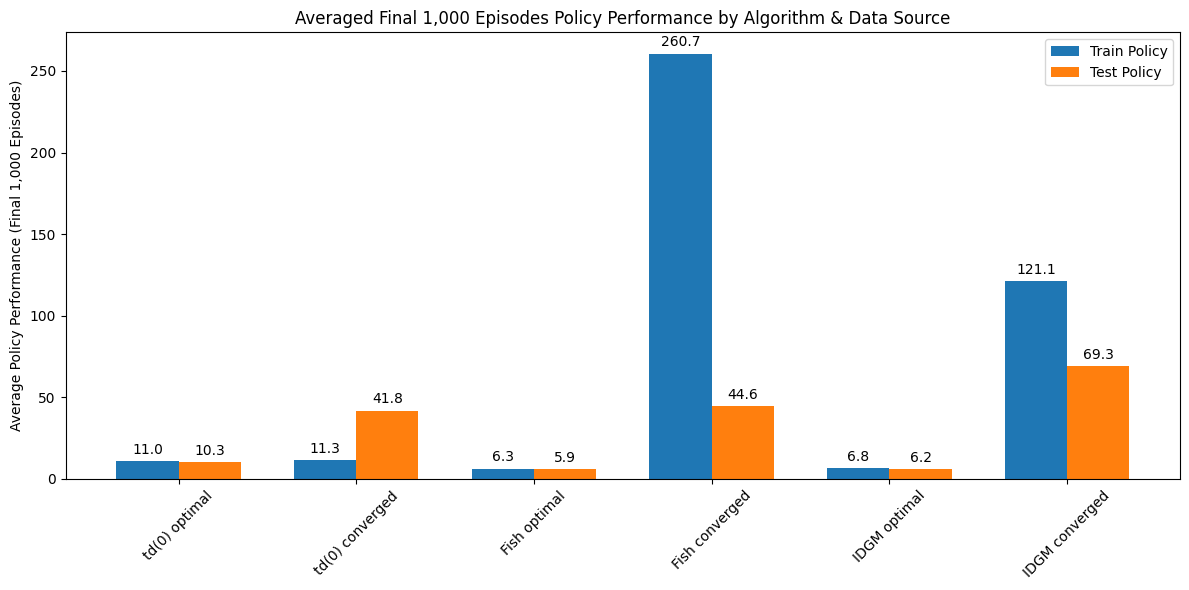

In [1]:
# Authenticate in Google Colab (if using Colab)
from google.colab import auth
auth.authenticate_user()

import numpy as np
import gspread
from google.auth import default
import itertools
import matplotlib.pyplot as plt
import time

# Authorize and create the client for Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# We'll extract the final 1000 episodes data.
# Data is tracked every 100 episodes, so we have episodes 9000, 9100, ... 10000 (11 points).
n_last = 11

def fetch_converged_trials(algorithm, param_indices):
    """
    For a given worksheet (identified by the hyperparameter indices in param_indices),
    fetch the data for train policy, test policy, train MSE and test MSE for each trial.
    A trial is considered converged if neither its train nor test policy exceeds 50,000.
    Returns a dictionary with lists of arrays (one per converged trial) for each metric.
    If the worksheet cannot be opened, returns None.
    """
    train_policy_list = []
    test_policy_list = []
    train_MSE_list = []
    test_MSE_list = []

    ws_name = f"{algorithm} {''.join(map(str, param_indices))}"
    try:
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(ws_name)
    except Exception as e:
        print(f"Could not open worksheet {ws_name}: {e}")
        return None

    for trial in range(5):
        offset = trial * 5
        try:
            # Columns:
            # Train policy: col 3+offset, Test policy: col 4+offset,
            # Train MSE: col 5+offset, Test MSE: col 6+offset.
            train_policy_all = np.array(worksheet.col_values(3 + offset)[3:], dtype=np.float64)
            test_policy_all = np.array(worksheet.col_values(4 + offset)[3:], dtype=np.float64)
            train_MSE_all = np.array(worksheet.col_values(5 + offset)[3:], dtype=np.float64)
            test_MSE_all = np.array(worksheet.col_values(6 + offset)[3:], dtype=np.float64)

            # Check for divergence:
            if np.max(train_policy_all) > 50000 or np.max(test_policy_all) > 50000:
                # Skip this trial if it diverged.
                continue

            # Extract the last n_last values (episodes 9000 to 10000)
            train_policy_list.append(train_policy_all[-n_last:])
            test_policy_list.append(test_policy_all[-n_last:])
            train_MSE_list.append(train_MSE_all[-n_last:])
            test_MSE_list.append(test_MSE_all[-n_last:])
        except Exception as e:
            print(f"Failed to fetch trial {trial} for {ws_name}: {e}")
            continue
        time.sleep(1)

    if len(train_policy_list) == 0:
        return None

    return {
        'train_policy_trials': train_policy_list,
        'test_policy_trials': test_policy_list,
        'train_MSE_trials': train_MSE_list,
        'test_MSE_trials': test_MSE_list
    }

def get_best_configuration(algorithm, param_grid):
    """
    Iterate over all hyperparameter configurations for the given algorithm,
    and select the configuration (using converged trials only) that has the lowest
    average test policy performance (averaged over the last n_last episodes).
    Returns both the configuration and the averaged metric arrays.
    """
    best_config = None
    best_metrics = None
    best_avg_test = np.inf

    for config in itertools.product(*param_grid):
        # Build indices (1-indexed)
        param_indices = [param_grid[i].index(value) + 1 for i, value in enumerate(config)]
        metrics = fetch_converged_trials(algorithm, param_indices)
        if metrics is None:
            continue
        # Compute scalar average test performance over the final 1000 episodes
        avg_test = np.mean(np.concatenate(metrics['test_policy_trials']))
        # Use lower average test performance as "better" (adjust if needed)
        if avg_test < best_avg_test:
            best_avg_test = avg_test
            best_config = config
            # Average each metric across all converged trials (element-wise over n_last data points)
            best_metrics = {
                'train_policy': np.nanmean(np.stack(metrics['train_policy_trials']), axis=0),
                'test_policy': np.nanmean(np.stack(metrics['test_policy_trials']), axis=0),
                'train_MSE': np.nanmean(np.stack(metrics['train_MSE_trials']), axis=0),
                'test_MSE': np.nanmean(np.stack(metrics['test_MSE_trials']), axis=0)
            }
        print(f"{algorithm} config {config}: Avg Test Policy = {avg_test:.3f}")

    if best_config is not None:
        print(f"\nBest configuration for {algorithm}: {best_config} with average test policy = {best_avg_test:.3f}\n")
    else:
        print(f"No valid configuration found for {algorithm}")
    return best_config, best_metrics

def get_all_converged_metrics(algorithm, param_grid):
    """
    Iterate over all hyperparameter configurations for the given algorithm,
    accumulate all converged trials (last n_last episodes) for each metric,
    and return overall averaged arrays.
    """
    all_train_policy_trials = []
    all_test_policy_trials = []
    all_train_MSE_trials = []
    all_test_MSE_trials = []

    for config in itertools.product(*param_grid):
        param_indices = [param_grid[i].index(value) + 1 for i, value in enumerate(config)]
        metrics = fetch_converged_trials(algorithm, param_indices)
        if metrics is None:
            continue
        all_train_policy_trials.extend(metrics['train_policy_trials'])
        all_test_policy_trials.extend(metrics['test_policy_trials'])
        all_train_MSE_trials.extend(metrics['train_MSE_trials'])
        all_test_MSE_trials.extend(metrics['test_MSE_trials'])

    if len(all_train_policy_trials) == 0:
        return None

    return {
        'train_policy': np.nanmean(np.stack(all_train_policy_trials), axis=0),
        'test_policy': np.nanmean(np.stack(all_test_policy_trials), axis=0),
        'train_MSE': np.nanmean(np.stack(all_train_MSE_trials), axis=0),
        'test_MSE': np.nanmean(np.stack(all_test_MSE_trials), axis=0)
    }

# Define parameter grids
td0_param = [[0.01, 0.05, 0.1], [2, 3, 4]]              # [Learning Rate, Degree]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]    # [Learning Rate, Outer Step Size, Degree]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]] # [Learning Rate, Outer Step Size, Degree]

# For each algorithm, compute:
# 1. The overall average from the best hyperparameter configuration.
# 2. The overall average from all converged trials.
algorithms = ['td(0)', 'Fish', 'IDGM']
param_grids = [td0_param, fish_param, idgm_param]

optimal_results = {}
all_results = {}

for alg, param in zip(algorithms, param_grids):
    print(f"Processing algorithm: {alg}")
    best_config, best_metrics = get_best_configuration(alg, param)
    all_metrics = get_all_converged_metrics(alg, param)

    if best_metrics is None or all_metrics is None:
        print(f"Insufficient data for {alg}")
        continue

    # For each, compute the overall average over the final 1000 episodes.
    optimal_train_avg = np.mean(best_metrics['train_policy'])
    optimal_test_avg  = np.mean(best_metrics['test_policy'])
    all_train_avg     = np.mean(all_metrics['train_policy'])
    all_test_avg      = np.mean(all_metrics['test_policy'])

    optimal_results[alg] = {'train': optimal_train_avg, 'test': optimal_test_avg}
    all_results[alg] = {'train': all_train_avg, 'test': all_test_avg}

# Create a grouped bar chart.
# We'll have 6 groups: for each algorithm, one group for optimal hyperparameters and one for all converged trials.
group_names = [
    "td(0) optimal", "td(0) converged",
    "Fish optimal", "Fish converged",
    "IDGM optimal", "IDGM converged"
]
train_vals = []
test_vals = []

for alg in algorithms:
    # Best hyperparameter configuration
    train_vals.append(optimal_results[alg]['train'])
    test_vals.append(optimal_results[alg]['test'])
    # All converged trials
    train_vals.append(all_results[alg]['train'])
    test_vals.append(all_results[alg]['test'])

x = np.arange(len(group_names))  # 6 groups
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_train = ax.bar(x - bar_width/2, train_vals, bar_width, label='Train Policy')
bars_test  = ax.bar(x + bar_width/2, test_vals,  bar_width, label='Test Policy')

ax.set_ylabel('Average Policy Performance (Final 1,000 Episodes)')
ax.set_title('Averaged Final 1,000 Episodes Policy Performance by Algorithm & Data Source')
ax.set_xticks(x)
ax.set_xticklabels(group_names, rotation=45)
ax.legend()

# Annotate bars with values
for bar in bars_train + bars_test:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

Plotting hyperparameter bar chart for td(0) ...


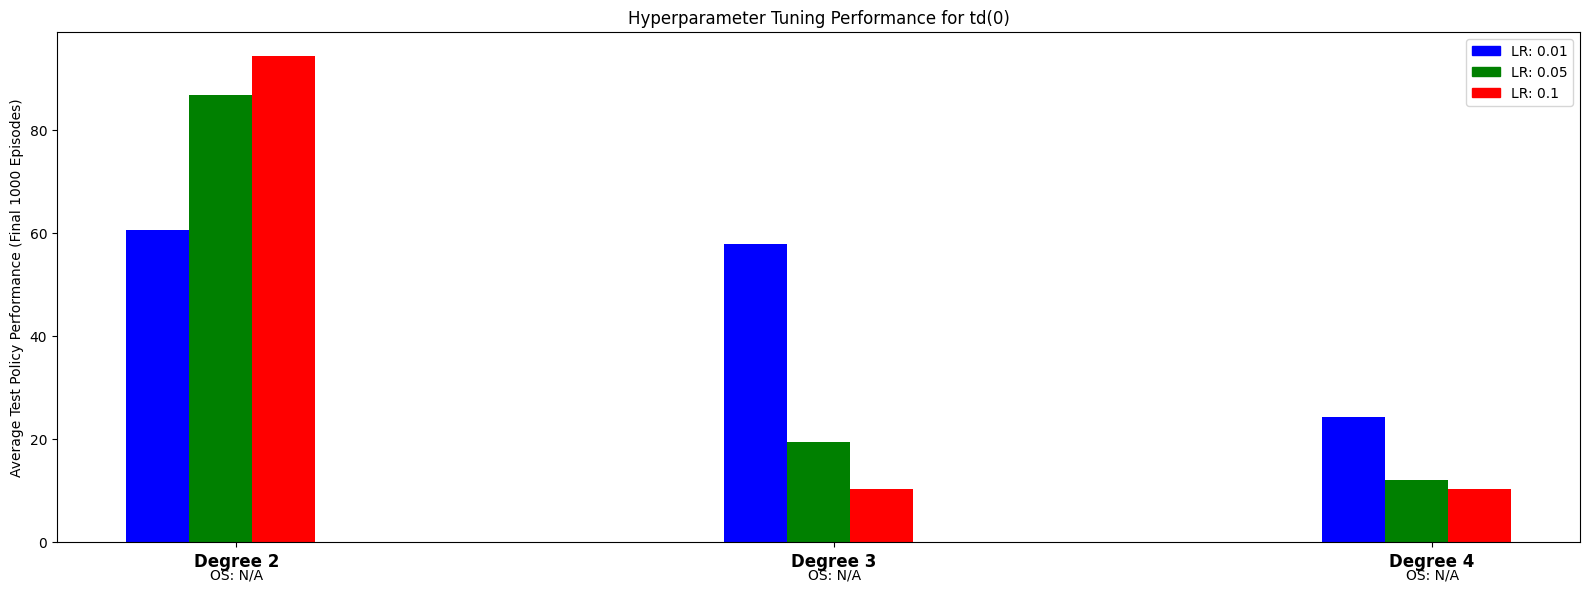

Plotting hyperparameter bar chart for Fish ...


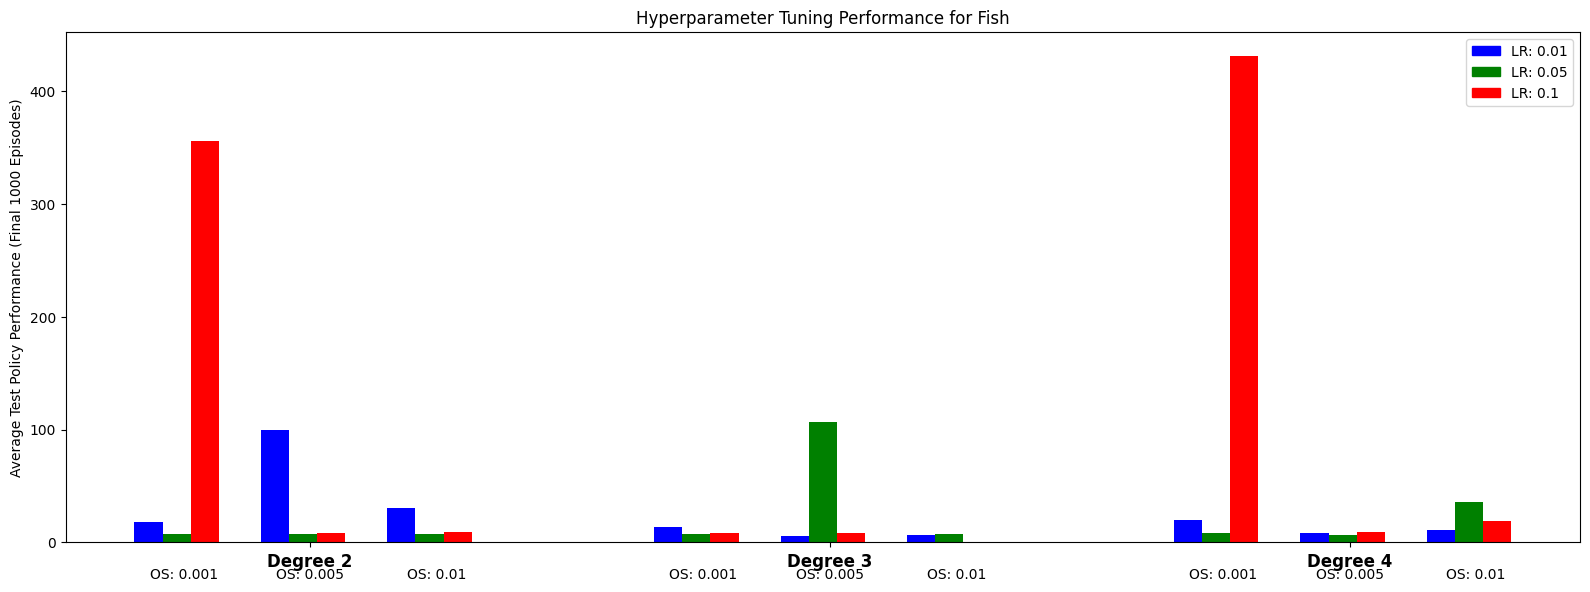

Plotting hyperparameter bar chart for IDGM ...


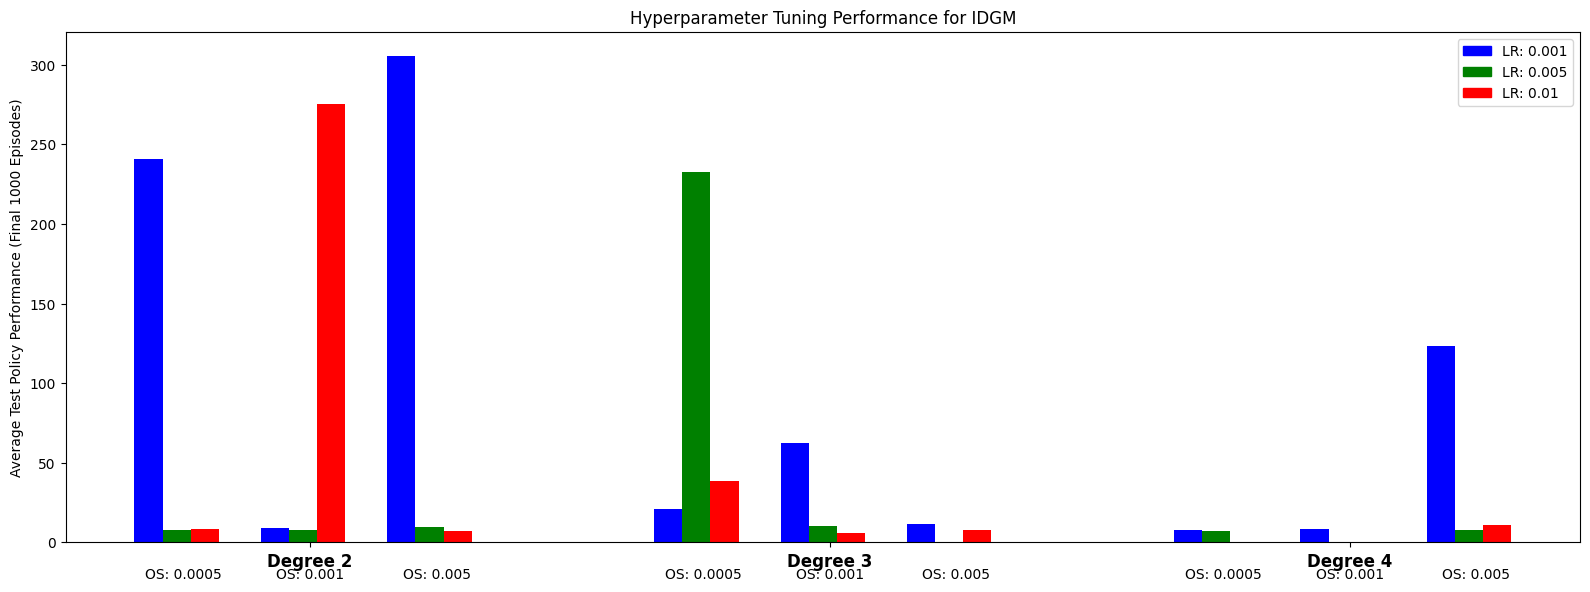

In [2]:
# Authenticate in Google Colab (if using Colab)
from google.colab import auth
auth.authenticate_user()

import numpy as np
import matplotlib.pyplot as plt
import gspread
from google.auth import default
import itertools
import time
from matplotlib.patches import Patch

# Authorize and create the client for Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Use the same criteria as before:
# - Data from the final 1000 episodes (recorded every 100 episodes: episodes 9000 to 10000, i.e. 11 points)
# - Exclude any trial as diverged if max(train, test policy) > 50,000.
# We'll use the helper function defined earlier to fetch converged trials for a given configuration.

n_last = 11  # final 11 data points (episodes 9000...10000)

def fetch_converged_trials(algorithm, param_indices):
    """
    Given the worksheet identified by the hyperparameter indices,
    fetch the lists (one per trial) for test policy performance for each trial.
    A trial is considered converged if neither its train nor test policy exceeds 50,000.
    Returns a dictionary with key 'test_policy_trials' (each is an array of length n_last),
    or returns None if no trial converged or the worksheet is unavailable.
    """
    test_policy_list = []

    ws_name = f"{algorithm} {''.join(map(str, param_indices))}"
    try:
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(ws_name)
    except Exception as e:
        # If worksheet not available, return None.
        # Uncomment next line to see errors:
        # print(f"Could not open worksheet {ws_name}: {e}")
        return None

    for trial in range(5):
        offset = trial * 5
        try:
            # For each trial, columns: Train policy (3+offset), Test policy (4+offset)
            # (We use test policy as our performance metric here.)
            train_policy_all = np.array(worksheet.col_values(3 + offset)[3:], dtype=np.float64)
            test_policy_all = np.array(worksheet.col_values(4 + offset)[3:], dtype=np.float64)

            # Check for divergence:
            if np.max(train_policy_all) > 50000 or np.max(test_policy_all) > 50000:
                continue  # skip this trial

            # Extract final 1000 episodes data (last 11 points)
            test_policy_list.append(test_policy_all[-n_last:])
        except Exception as e:
            # If any error, skip this trial
            continue
        time.sleep(1)

    if len(test_policy_list) == 0:
        return None
    return {'test_policy_trials': test_policy_list}

def plot_hyperparameter_bar_chart(algorithm, param_grid):
    """
    For the given algorithm and its hyperparameter grid, this function:
      - Iterates over all configurations.
      - Computes the average test policy performance (over the last 1000 episodes, averaged across converged trials)
        for each configuration.
      - Plots a bar chart with hierarchical grouping:
          • The major groups on the x-axis are the degree values.
          • Within each degree group, there are minor groups for each outer step size.
          • Within each minor group, there are side-by-side bars (different colors) for each learning rate.
    For TD(0) (which lacks an outer step size), a single dummy outer step size group ("N/A") is used.
    """
    # Determine parameter ordering based on algorithm:
    # For Fish and IDGM: param_grid = [learning_rate, outer_step_size, degree]
    # For td(0): param_grid = [learning_rate, degree]  → we treat outer_step_size as a single group "N/A"
    if algorithm.lower() == 'td(0)':
        lr_list = param_grid[0]
        degree_list = param_grid[1]
        outer_list = ['N/A']
    else:
        lr_list = param_grid[0]
        outer_list = param_grid[1]
        degree_list = param_grid[2]

    # Parameters for spacing:
    bar_width = 0.2
    minor_gap = 0.3   # gap between outer step size groups
    major_gap = 1.0   # gap between degree groups

    x_positions = []  # x position for each bar
    bar_heights = []  # average test performance for each configuration
    bar_colors = []   # color based on learning rate

    # For hierarchical labels, record centers:
    degree_group_centers = []  # (degree, x_center)
    outer_group_centers = []   # list of (degree, outer, x_center)

    # Colors for learning rates (assuming 3 values):
    lr_colors = ['blue', 'green', 'red']

    current_x = 0
    # Loop over degree groups (largest groups)
    for d_idx, degree in enumerate(degree_list):
        degree_start_x = current_x
        # For each outer step size group (if td(0), there's just one group "N/A")
        for o_idx, outer in enumerate(outer_list):
            outer_start_x = current_x
            # For each learning rate (3 bars side-by-side)
            for l_idx, lr in enumerate(lr_list):
                # Build parameter indices depending on algorithm.
                if algorithm.lower() == 'td(0)':
                    # Worksheet naming for td(0) expects two indices: [lr, degree]
                    param_indices = [lr_list.index(lr)+1, degree_list.index(degree)+1]
                else:
                    # For Fish and IDGM: indices are [lr, outer, degree]
                    param_indices = [lr_list.index(lr)+1, outer_list.index(outer)+1, degree_list.index(degree)+1]

                # Fetch data for this configuration.
                result = fetch_converged_trials(algorithm, param_indices)
                if result is None:
                    avg_value = np.nan
                else:
                    # Average over all converged trials (flatten the final 1000 episodes data)
                    avg_value = np.mean(np.concatenate(result['test_policy_trials']))
                bar_heights.append(avg_value)
                x_positions.append(current_x)
                bar_colors.append(lr_colors[l_idx] if l_idx < len(lr_colors) else 'gray')
                current_x += bar_width  # move to next bar in the small group
            # Compute center of this outer step size group
            outer_center = (outer_start_x + current_x - bar_width/2) / 2
            outer_group_centers.append((degree, outer, outer_center))
            current_x += minor_gap  # add gap after outer group
        # End of degree group: record center and add major gap
        degree_end_x = current_x - minor_gap  # remove last minor gap
        degree_center = (degree_start_x + degree_end_x - bar_width/2) / 2
        degree_group_centers.append((degree, degree_center))
        current_x += major_gap  # gap after degree group

    # Create the bar chart.
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x_positions, bar_heights, width=bar_width, color=bar_colors)
    ax.set_ylabel('Average Test Policy Performance (Final 1000 Episodes)')
    ax.set_title(f'Hyperparameter Tuning Performance for {algorithm}')

    # Set major x-axis ticks for degree groups.
    major_tick_positions = [center for (deg, center) in degree_group_centers]
    major_tick_labels = [f'Degree {deg}' for (deg, center) in degree_group_centers]
    ax.set_xticks(major_tick_positions)
    ax.set_xticklabels(major_tick_labels, fontsize=12, fontweight='bold')

    # Add annotations for outer step size groups:
    # We place these below the x-axis. We'll compute the min y for placement.
    y_min, y_max = ax.get_ylim()
    for (deg, outer, center) in outer_group_centers:
        ax.text(center, y_min - 0.05*(y_max-y_min), f'OS: {outer}',
                ha='center', va='top', fontsize=10, rotation=0)

    # Create legend for learning rates.
    legend_handles = [Patch(color=lr_colors[i], label=f'LR: {lr}') for i, lr in enumerate(lr_list)]
    ax.legend(handles=legend_handles)

    plt.tight_layout()
    plt.show()

# Define parameter grids
td0_param = [[0.01, 0.05, 0.1], [2, 3, 4]]              # [Learning Rate, Degree]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]    # [Learning Rate, Outer Step Size, Degree]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]] # [Learning Rate, Outer Step Size, Degree]

# Now plot one chart per algorithm.
for algorithm, param_grid in [('td(0)', td0_param), ('Fish', fish_param), ('IDGM', idgm_param)]:
    print(f"Plotting hyperparameter bar chart for {algorithm} ...")
    plot_hyperparameter_bar_chart(algorithm, param_grid)


In [5]:
# Authenticate in Google Colab (if using Colab)
from google.colab import auth
auth.authenticate_user()

import numpy as np
import matplotlib.pyplot as plt
import gspread
from google.auth import default
import itertools
import time
from matplotlib.patches import Patch

# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Settings: data is recorded every 100 episodes, and we want the final 1000 episodes → 11 data points.
n_last = 11

def fetch_converged_trials(algorithm, param_indices, metric='test'):
    """
    Given a worksheet (named by concatenating the algorithm and 1-indexed param_indices),
    fetch the final n_last data points for each trial for the chosen metric ('test' or 'train').
    A trial is included only if its maximum train AND test values do not exceed 50,000.

    Returns a list of arrays (each array length n_last) or None if no trial converged.
    """
    ws_name = f"{algorithm} {''.join(map(str, param_indices))}"
    try:
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(ws_name)
    except Exception as e:
        # Could not open worksheet—likely a naming issue.
        print(f"Could not open worksheet {ws_name}: {e}")
        return None

    valid_trials = []
    for trial in range(5):
        offset = trial * 5
        try:
            # Columns: Train policy at col (3+offset), Test policy at col (4+offset)
            train_vals = np.array(worksheet.col_values(3 + offset)[3:], dtype=np.float64)
            test_vals  = np.array(worksheet.col_values(4 + offset)[3:], dtype=np.float64)
            # If either metric exceeds 50,000, skip the trial.
            if np.max(train_vals) > 50000 or np.max(test_vals) > 50000:
                # Uncomment the next line for debugging:
                # print(f"Worksheet {ws_name} trial {trial} diverged.")
                continue
            # Select final n_last data points.
            if metric == 'test':
                vals = test_vals[-n_last:]
            elif metric == 'train':
                vals = train_vals[-n_last:]
            else:
                vals = None
            if vals is not None:
                valid_trials.append(vals)
        except Exception as e:
            print(f"Error processing worksheet {ws_name}, trial {trial}: {e}")
            continue
        time.sleep(1)  # pause to avoid API rate limits
    if len(valid_trials) == 0:
        return None
    return valid_trials

def plot_hyperparameter_bar_chart(algorithm, param_grid, metric='test'):
    """
    For the given algorithm and hyperparameter grid, iterate over all configurations,
    compute the average performance (averaged over the final 1000 episodes and over converged trials)
    for each configuration, and then plot a hierarchical bar chart.

    The x-axis is arranged as:
      - Major groups: degree values.
      - Minor groups within each degree: outer step sizes.
      - Within each minor group: three bars for different learning rates (colored distinctly).

    For Fish and IDGM, the y-axis is logarithmic.

    After plotting, the function prints the average value for each bar.
    """
    # For Fish and IDGM: param_grid = [learning_rates, outer_step_sizes, degrees]
    # For td(0): param_grid = [learning_rates, degrees] → treat outer step as a single group "N/A".
    if algorithm.lower() == 'td(0)':
        lr_list = param_grid[0]
        degree_list = param_grid[1]
        outer_list = ['N/A']
    else:
        lr_list = param_grid[0]
        outer_list = param_grid[1]
        degree_list = param_grid[2]

    # Spacing parameters for hierarchical grouping.
    bar_width = 0.2
    minor_gap = 0.3   # gap between outer step groups
    major_gap = 1.0   # gap between degree groups

    x_positions = []   # x positions for each bar
    bar_heights = []   # computed average values for each configuration (bar)
    bar_colors = []    # colors for different learning rates
    # We'll also store the computed averages for printing.
    results = {}  # {degree: {outer: {lr: avg_value}}}

    # Colors for learning rates (assuming 3 values):
    lr_colors = ['blue', 'green', 'red']

    # For group label positions.
    degree_centers = []
    outer_centers = []

    current_x = 0
    for d in degree_list:
        results[d] = {}
        degree_start = current_x
        for o in outer_list:
            results[d][o] = {}
            outer_start = current_x
            for lr in lr_list:
                # Build the worksheet indices (1-indexed).
                if algorithm.lower() == 'td(0)':
                    param_indices = [lr_list.index(lr) + 1, degree_list.index(d) + 1]
                else:
                    param_indices = [lr_list.index(lr) + 1, outer_list.index(o) + 1, degree_list.index(d) + 1]
                trial_data = fetch_converged_trials(algorithm, param_indices, metric=metric)
                if trial_data is None:
                    avg_value = np.nan
                else:
                    # Flatten all valid trials' final data and compute the mean.
                    avg_value = np.mean(np.concatenate(trial_data))
                results[d][o][lr] = avg_value
                bar_heights.append(avg_value)
                x_positions.append(current_x)
                bar_colors.append(lr_colors[lr_list.index(lr)] if lr_list.index(lr) < len(lr_colors) else 'gray')
                current_x += bar_width
            # Compute center of the minor group (outer step group).
            outer_center = (outer_start + current_x - bar_width/2) / 2
            outer_centers.append((d, o, outer_center))
            current_x += minor_gap  # gap after minor group
        # Compute center of the major group (degree group).
        degree_end = current_x - minor_gap
        degree_center = (degree_start + degree_end - bar_width/2) / 2
        degree_centers.append((d, degree_center))
        current_x += major_gap  # gap after major group

    # Plot the bar chart.
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x_positions, bar_heights, width=bar_width, color=bar_colors)
    ax.set_ylabel(f"Average {metric.capitalize()} Policy Performance (Final 1000 Episodes)")
    ax.set_title(f"{algorithm} - {metric.capitalize()} Policy Performance by Hyperparameter Tuning")

    # For Fish and IDGM, set y-axis logarithmic.
    if algorithm.lower() in ['fish', 'idgm']:
        ax.set_yscale('log')

    # Set x-axis ticks for major groups (degrees).
    major_ticks = [center for (deg, center) in degree_centers]
    major_labels = [f"Degree {deg}" for (deg, center) in degree_centers]
    ax.set_xticks(major_ticks)
    ax.set_xticklabels(major_labels, fontsize=12, fontweight='bold')

    # Annotate minor groups (outer step sizes) below the x-axis.
    y_min, y_max = ax.get_ylim()
    for (d, o, center) in outer_centers:
        ax.text(center, y_min - 0.05*(y_max-y_min), f"OS: {o}",
                ha='center', va='top', fontsize=10)

    # Create a legend for learning rates.
    legend_handles = [Patch(color=lr_colors[i], label=f"LR: {lr}") for i, lr in enumerate(lr_list)]
    ax.legend(handles=legend_handles)

    plt.tight_layout()
    plt.show()

    # Print the average values for each bar.
    print(f"\nAverage {metric.capitalize()} Policy Performance for {algorithm}:")
    for d in results:
        for o in results[d]:
            for lr in results[d][o]:
                val = results[d][o][lr]
                print(f"Degree {d}, Outer Step Size {o}, LR {lr}: {val:.3f}")

    return results

# Define parameter grids.
td0_param  = [[0.01, 0.05, 0.1], [2, 3, 4]]              # [Learning Rate, Degree]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]    # [Learning Rate, Outer Step Size, Degree]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]] # [Learning Rate, Outer Step Size, Degree]

# Plot for each algorithm:
algorithms = [('td(0)', td0_param), ('Fish', fish_param), ('IDGM', idgm_param)]
metrics = ['test', 'train']

for alg, grid in algorithms:
    for met in metrics:
        print(f"\nPlotting {met.capitalize()} Policy Bar Chart for {alg}")
        plot_hyperparameter_bar_chart(alg, grid, metric=met)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Authenticate in Google Colab (if using Colab)
from google.colab import auth
auth.authenticate_user()

import numpy as np
import matplotlib.pyplot as plt
import gspread
from google.auth import default
import itertools
import time
from matplotlib.patches import Patch

# Authorize Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Settings: data is recorded every 100 episodes, and we want the final 1000 episodes (11 data points)
n_last = 11

def fetch_converged_trials(algorithm, param_indices, metric='test'):
    """
    Given a worksheet (named by concatenating the algorithm and 1-indexed param_indices),
    fetch the final n_last data points for each trial for the chosen metric ('test' or 'train').
    A trial is included only if its maximum train AND test values do not exceed 50,000.

    Returns a list of arrays (each array length n_last) or None if no trial converged.
    """
    ws_name = f"{algorithm} {''.join(map(str, param_indices))}"
    try:
        worksheet = gc.open('Combined Data Tables AP Research').worksheet(ws_name)
    except Exception as e:
        print(f"[DEBUG] Could not open worksheet {ws_name}: {e}")
        return None

    valid_trials = []
    for trial in range(5):
        offset = trial * 5
        try:
            # Columns: Train policy at col (3+offset), Test policy at col (4+offset)
            train_vals = np.array(worksheet.col_values(3 + offset)[3:], dtype=np.float64)
            test_vals  = np.array(worksheet.col_values(4 + offset)[3:], dtype=np.float64)
            if np.max(train_vals) > 50000 or np.max(test_vals) > 50000:
                #print(f"[DEBUG] {ws_name} trial {trial} diverged.")
                continue
            if metric == 'test':
                vals = test_vals[-n_last:]
            elif metric == 'train':
                vals = train_vals[-n_last:]
            else:
                vals = None
            if vals is not None:
                valid_trials.append(vals)
        except Exception as e:
            print(f"[DEBUG] Error processing {ws_name} trial {trial}: {e}")
            continue
        time.sleep(1)
    if len(valid_trials) == 0:
        print(f"[DEBUG] No converged trials in {ws_name}.")
        return None
    return valid_trials

def plot_hyperparameter_bar_chart(algorithm, param_grid, metric='test'):
    """
    For the given algorithm and hyperparameter grid, iterate over all configurations,
    compute the average performance (averaged over the final 1000 episodes and over converged trials)
    for each configuration, and then plot a hierarchical bar chart.

    The x-axis is arranged as:
      - Major groups (with large gaps) represent the degree values.
      - Within each degree, minor groups (with smaller gaps) represent the outer step sizes.
      - Within each minor group, three side-by-side bars (different colors) represent learning rates.

    For Fish and IDGM the y-axis is set to logarithmic.
    After plotting, the function prints out the average value for each bar.
    """
    # For Fish and IDGM: param_grid = [learning_rates, outer_step_sizes, degrees]
    # For td(0): param_grid = [learning_rates, degrees] → use dummy outer group "N/A".
    if algorithm.lower() == 'td(0)':
        lr_list = param_grid[0]
        degree_list = param_grid[1]
        outer_list = ['N/A']
    else:
        lr_list = param_grid[0]
        outer_list = param_grid[1]
        degree_list = param_grid[2]

    # Spacing parameters.
    bar_width = 0.2
    minor_gap = 0.3   # gap between outer groups
    major_gap = 1.0   # gap between degree groups

    x_positions = []   # positions for each bar
    bar_heights = []   # computed average values for each configuration (bar)
    bar_colors = []    # colors for different learning rates

    # For later printing.
    results = {}  # {degree: {outer: {lr: avg_value}}}

    # Colors for learning rates (assume 3).
    lr_colors = ['blue', 'green', 'red']

    # For group labels.
    degree_centers = []
    outer_centers = []

    current_x = 0
    for d in degree_list:
        results[d] = {}
        degree_start = current_x
        for o in outer_list:
            results[d][o] = {}
            outer_start = current_x
            for lr in lr_list:
                if algorithm.lower() == 'td(0)':
                    param_indices = [lr_list.index(lr) + 1, degree_list.index(d) + 1]
                else:
                    param_indices = [lr_list.index(lr) + 1, outer_list.index(o) + 1, degree_list.index(d) + 1]
                trial_data = fetch_converged_trials(algorithm, param_indices, metric=metric)
                if trial_data is None:
                    avg_value = np.nan
                else:
                    avg_value = np.mean(np.concatenate(trial_data))
                results[d][o][lr] = avg_value
                bar_heights.append(avg_value)
                x_positions.append(current_x)
                bar_colors.append(lr_colors[lr_list.index(lr)] if lr_list.index(lr) < len(lr_colors) else 'gray')
                current_x += bar_width
            # End of learning rates in one minor group.
            outer_center = (outer_start + current_x - bar_width/2) / 2
            outer_centers.append((d, o, outer_center))
            current_x += minor_gap
        # End of one degree group.
        degree_end = current_x - minor_gap
        degree_center = (degree_start + degree_end - bar_width/2) / 2
        degree_centers.append((d, degree_center))
        current_x += major_gap

    # Debug print of bar heights.
    print(f"[DEBUG] {algorithm} - {metric} bar heights: {bar_heights}")

    # If for Fish/IDGM many values are NaN or <=0, log scale can fail.
    valid_values = [v for v in bar_heights if (not np.isnan(v)) and (v > 0)]
    if len(valid_values) == 0:
        print(f"[DEBUG] No valid {metric} data found for {algorithm}.")
        return results

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x_positions, bar_heights, width=bar_width, color=bar_colors)
    ax.set_ylabel(f"Average {metric.capitalize()} Policy Performance (Final 1000 Episodes)")
    ax.set_title(f"{algorithm} - {metric.capitalize()} Policy Performance by Hyperparameter Tuning")

    # Set y-axis logarithmic for Fish and IDGM if valid.
    if algorithm.lower() in ['fish', 'idgm']:
        min_val = min(valid_values)
        if min_val > 0:
            ax.set_yscale('log')
        else:
            print(f"[DEBUG] {algorithm} {metric}: Non-positive values found, cannot set log scale.")

    # Set x-axis ticks for major groups (degrees).
    major_ticks = [center for (_, center) in degree_centers]
    major_labels = [f"Degree {d}" for (d, center) in degree_centers]
    ax.set_xticks(major_ticks)
    ax.set_xticklabels(major_labels, fontsize=12, fontweight='bold')

    # Annotate minor groups (outer step sizes) below the x-axis.
    y_min, y_max = ax.get_ylim()
    for (d, o, center) in outer_centers:
        ax.text(center, y_min - 0.07*(y_max-y_min), f"OS: {o}",
                ha='center', va='top', fontsize=10)

    # Adjust layout to reserve space at bottom.
    plt.tight_layout(rect=[0, 0.15, 1, 1])

    # Legend for learning rates.
    legend_handles = [Patch(color=lr_colors[i], label=f"LR: {lr}") for i, lr in enumerate(lr_list)]
    ax.legend(handles=legend_handles)

    plt.subplots_adjust(bottom=0.25)  # increase bottom margin for annotations
    #plt.show()

    # Print out the average values.
    print(f"\nAverage {metric.capitalize()} Policy Performance for {algorithm}:")
    for d in results:
        for o in results[d]:
            for lr in results[d][o]:
                val = results[d][o][lr]
                print(f"Degree {d}, Outer Step Size {o}, LR {lr}: {val:.3f}")

    return results

# Define parameter grids.
td0_param  = [[0.01, 0.05, 0.1], [2, 3, 4]]              # [Learning Rate, Degree]
fish_param = [[0.01, 0.05, 0.1], [0.001, 0.005, 0.01], [2, 3, 4]]    # [Learning Rate, Outer Step Size, Degree]
idgm_param = [[0.001, 0.005, 0.01], [0.0005, 0.001, 0.005], [2, 3, 4]] # [Learning Rate, Outer Step Size, Degree]

# Plot for each algorithm and for both metrics.
algorithms = [('td(0)', td0_param), ('Fish', fish_param), ('IDGM', idgm_param)]
for alg, grid in algorithms:
    for met in ['test', 'train']:
        print(f"\nPlotting {met.capitalize()} Policy Bar Chart for {alg}")
        plot_hyperparameter_bar_chart(alg, grid, metric=met)